# Evaluation: DeepInspire vs Classification CNN

This notebook evaluates both approaches on the test dataset:
1. **DeepInspire**: Segmentation-based ROL (Rib-Over-Lung) analysis
2. **Classification CNN**: Direct classification with GradCAM visualization

The evaluation includes:
- Confusion matrices
- Performance metrics (Accuracy, Sensitivity, Specificity, Precision, F1)
- ROC curves with AUC
- Statistical comparison (McNemar's test)
- 95% confidence intervals
- False positives/negatives analysis

## 1. Import Libraries

In [1]:
import glob
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torchvision import transforms, models
import matplotlib.pyplot as plt
import numpy as np
from torch import nn, optim
from tqdm import tqdm
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, precision_score, recall_score, f1_score
import seaborn as sns
import datetime
import segmentation_models_pytorch as smp
import time
from IPython.display import display, clear_output
from skimage import color
import pandas as pd
from scipy import stats
import os
import tifffile as tiff

/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'dlopen(/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.10/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <52D1D93C-FC3D-335D-8475-03482908DF9F> /opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.10/site-packages/torchvision/image.so
  Expected in:     <ECC148AF-20FF-3EEE-BC75-4DD3E7455393> /opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.10/site-packages/torch/lib/libtorch_cpu.dylib'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


## 2. Load Models

In [2]:
# Set device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Model paths
lung_model_path = '../train_result/trained_models/lung_MAnet_20260209_042722_best.pth'
rib_model_path = '../train_result/trained_models/rib_MAnet_20260209_034825_best.pth'
classification_model_path = '../train_result/trained_models/Classification_resnet34_20260209_051509_best.pth'

# Dataset path - Updated for new folder structure
ROL_cal_image_folder = '../2026 Dataset/train'  # Contains full/ and not full/ with image/ subfolders
test_image_folder = '../2026 Dataset/test'  # Contains full/ and not full/ with image/ subfolders

# Tech interprete CSV
tech_data_path = '../Result/2026 Tech interpretecsv.csv'

Using device: cpu


In [3]:
class MAnetWithDropout(nn.Module):
    """MAnet wrapper that applies spatial dropout on decoder features."""

    def __init__(self, dropout_p=0.2, **manet_kwargs):
        super().__init__()
        self.model = smp.MAnet(**manet_kwargs)
        self.dropout = nn.Dropout2d(p=dropout_p)
        self.dropout_p = dropout_p
        
    def name(self):
        return f"MAnetWithDropout_{self.dropout_p}"

    def forward(self, x):
        features = self.model.encoder(x)
        decoder_output = self.model.decoder(*features)
        decoder_output = self.dropout(decoder_output)
        masks = self.model.segmentation_head(decoder_output)

        if self.model.classification_head is not None:
            labels = self.model.classification_head(features[-1])
            return masks, labels

        return masks

In [4]:
# Load Rib & Lung Segmentation Models
SIZE_X = 512 
SIZE_Y = 512
# ENCODER = 'resnext50_32x4d'
ENCODER = 'resnet34'
ENCODER_WEIGHTS = 'imagenet'
activation = None

print("Loading rib model...")
# rib_model = smp.MAnet(encoder_name=ENCODER,
#                       encoder_weights=ENCODER_WEIGHTS,
#                       classes=3,
#                       in_channels=3,
#                       activation=activation)

rib_model = MAnetWithDropout(
                            dropout_p=0.4,
                            encoder_name=ENCODER,
                            encoder_weights=ENCODER_WEIGHTS,
                            in_channels=3,
                            classes=3
                        )
rib_model.to(device)
rib_pre_dict = torch.load(rib_model_path, map_location=device)
rib_model.load_state_dict(rib_pre_dict['model'])
rib_model.eval()
print("✓ Rib model loaded")

print("\nLoading lung model...")
# lung_model = smp.MAnet(encoder_name=ENCODER,
#                        encoder_weights=ENCODER_WEIGHTS,
#                        classes=3,
#                        in_channels=3,
#                        activation=activation)
lung_model = MAnetWithDropout(
                            dropout_p=0.4,
                            encoder_name=ENCODER,
                            encoder_weights=ENCODER_WEIGHTS,
                            in_channels=3,
                            classes=3
                        )
lung_model.to(device)
lung_pre_dict = torch.load(lung_model_path, map_location=device)
lung_model.load_state_dict(lung_pre_dict['model'])
lung_model.eval()
print("✓ Lung model loaded")

# Load Classification Model
print("Loading classification model...")
# model = models.resnext50_32x4d(weights='IMAGENET1K_V1').to(device)
model = models.resnet34(weights='IMAGENET1K_V1')
    
# Modify the final layer for binary classification (add dropout)
model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(model.fc.in_features, 2)
)
model = model.to(device)

state_dict = torch.load(classification_model_path, map_location=device)
model.load_state_dict(state_dict['model'])
model.eval()
print("✓ Classification model loaded")

print("\n" + "="*60)
print("ALL MODELS LOADED SUCCESSFULLY")
print("="*60)

Loading rib model...


/var/folders/g5/zsclc1cn68nbqrd2tbc037br0000gn/T/ipykernel_141/2909800228.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  rib_pre_dict = torch.load(rib_model_path, map_

✓ Rib model loaded

Loading lung model...


/var/folders/g5/zsclc1cn68nbqrd2tbc037br0000gn/T/ipykernel_141/2909800228.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  lung_pre_dict = torch.load(lung_model_path, ma

✓ Lung model loaded
Loading classification model...
✓ Classification model loaded

ALL MODELS LOADED SUCCESSFULLY


/var/folders/g5/zsclc1cn68nbqrd2tbc037br0000gn/T/ipykernel_141/2909800228.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(classification_model_p

## 3. Helper Functions

In [5]:
def np_to_torch(np_array):
    return torch.from_numpy(np_array).float()

def torch_to_np(torch_array):
    return np.squeeze(torch_array.detach().cpu().numpy())

def load_image(image_path):
    """Load and preprocess an image."""
    img = cv2.imread(image_path, 1)  # Read in BGR mode (1)
    img = cv2.resize(img, (512, 512), interpolation=cv2.INTER_NEAREST)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img / 255    
    img = img.astype(np.float64)
    image_float = img.copy()
    img = np.transpose(img, (2, 0, 1))
    img = np_to_torch(img)
    return img, image_float


In [6]:
def find_optimal_threshold_youden(y_true, y_scores, plot=True):
    """
    Find optimal classification threshold using Youden's J statistic.
    
    Youden's J statistic = Sensitivity + Specificity - 1 = TPR - FPR
    The optimal threshold maximizes this value.
    
    Args:
        y_true: True binary labels (0 or 1)
        y_scores: Predicted scores/probabilities for positive class
        plot: Whether to plot the ROC curve with optimal point
    
    Returns:
        optimal_threshold: Threshold that maximizes Youden's J
        optimal_j: Maximum Youden's J value
        optimal_sensitivity: Sensitivity at optimal threshold
        optimal_specificity: Specificity at optimal threshold
    """
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    
    # Calculate Youden's J statistic for each threshold
    # J = Sensitivity + Specificity - 1 = TPR + (1 - FPR) - 1 = TPR - FPR
    j_scores = tpr - fpr
    
    # Find the optimal threshold (maximum J)
    optimal_idx = np.argmax(j_scores)
    optimal_threshold = thresholds[optimal_idx]
    optimal_j = j_scores[optimal_idx]
    optimal_sensitivity = tpr[optimal_idx]
    optimal_specificity = 1 - fpr[optimal_idx]
    
    # Calculate AUC
    roc_auc = auc(fpr, tpr)
    
    print(f"Optimal Threshold (Youden's J): {optimal_threshold:.4f}")
    print(f"Maximum Youden's J: {optimal_j:.4f}")
    print(f"Sensitivity at optimal threshold: {optimal_sensitivity:.4f}")
    print(f"Specificity at optimal threshold: {optimal_specificity:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    
    if plot:
        plt.figure(figsize=(10, 8))
        
        # Plot ROC curve
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.4f})')
        
        # Plot diagonal reference line
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
                label='Random Classifier')
        
        # Mark optimal point
        plt.scatter(fpr[optimal_idx], tpr[optimal_idx], 
                   marker='o', color='red', s=200, 
                   label=f'Optimal Point (J={optimal_j:.4f})', 
                   edgecolors='black', linewidths=2, zorder=5)
        
        # Add annotation
        plt.annotate(f'Threshold: {optimal_threshold:.4f}\\n' + 
                    f'Sensitivity: {optimal_sensitivity:.4f}\\n' + 
                    f'Specificity: {optimal_specificity:.4f}',
                    xy=(fpr[optimal_idx], tpr[optimal_idx]),
                    xytext=(fpr[optimal_idx] + 0.15, tpr[optimal_idx] - 0.15),
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', 
                                  color='black', lw=1.5))
        
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
        plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
        plt.title('ROC Curve with Optimal Threshold (Youden\\s J Method)', 
                 fontsize=14, fontweight='bold')
        plt.legend(loc="lower right", fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    return {
        'optimal_threshold': optimal_threshold,
        'optimal_j': optimal_j,
        'sensitivity': optimal_sensitivity,
        'specificity': optimal_specificity,
        'auc': roc_auc,
        'fpr': fpr,
        'tpr': tpr,
        'thresholds': thresholds
    }

In [7]:
def calculate_optimal_rol_cutoff(test_folder, rib_model, lung_model, device):
    """
    Calculate optimal ROL cutoff using Youden's J method for DeepInspire approach.
    
    Args:
        test_folder: Path to test folder containing 'full' and 'not full' subfolders
        rib_model: Trained rib segmentation model
        lung_model: Trained lung segmentation model
        device: torch device (cpu or cuda)
    
    Returns:
        optimal_results: Dictionary containing optimal threshold and all metrics
    """
    print("=" * 80)
    print("CALCULATING OPTIMAL ROL CUTOFF FOR DEEPINSPIRE")
    print("=" * 80)
    
    # Load test images from new folder structure
    full_folder = os.path.join(test_folder, 'full', 'image')
    not_full_folder = os.path.join(test_folder, 'not full', 'image')
    
    full_images = [os.path.join(full_folder, f) for f in os.listdir(full_folder) 
                   if f.endswith(('.png', '.jpg', '.jpeg'))]
    not_full_images = [os.path.join(not_full_folder, f) for f in os.listdir(not_full_folder) 
                       if f.endswith(('.png', '.jpg', '.jpeg'))]
    
    print(f"\nTest Dataset:")
    print(f"  - Adequate inspiration (full): {len(full_images)} images")
    print(f"  - Inadequate inspiration (not full): {len(not_full_images)} images")
    print(f"  - Total: {len(full_images) + len(not_full_images)} images")
    
    # Ground truth labels
    # 0 = Adequate (Negative), 1 = Inadequate (Positive)
    y_true = [0] * len(full_images) + [1] * len(not_full_images)
    all_images = full_images + not_full_images
    
    # Storage for ROL scores
    rol_scores = []

    # Preprocessing function
    def preprocess_for_segmentation(img, device):
        preprocessing_fn = smp.encoders.get_preprocessing_fn(ENCODER, 'imagenet')
        img = preprocessing_fn(img)
        image = img.astype(np.float64)
        image = np.transpose(image, (2, 0, 1))
        img_input = np.expand_dims(image, 0)
        img_input = torch.from_numpy(img_input).float().to(device)
        return img_input
    
    print("\nProcessing images to calculate ROL...")
    
    # Process each image
    for image_path in tqdm(all_images):
        try:
            # Load image
            SIZE_X = 512
            SIZE_Y = 512
            original_image = cv2.imread(image_path, 1)
            original_image = cv2.resize(original_image, (SIZE_Y, SIZE_X), 
                                       interpolation=cv2.INTER_NEAREST)
            original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
            original_image = original_image / 255
            original_image = original_image.astype(np.float64)
            
            # Preprocess
            img_input = preprocess_for_segmentation(original_image.copy(), device)
            
            # Predict with rib model
            with torch.no_grad():
                r_y_pred = rib_model(img_input)
            r_y_pred_np = torch.squeeze(r_y_pred.detach().cpu()).numpy()
            r_y_pred_argmax = np.argmax(r_y_pred_np, axis=0)
            
            # Predict with lung model
            with torch.no_grad():
                l_y_pred = lung_model(img_input)
            l_y_pred_np = torch.squeeze(l_y_pred.detach().cpu()).numpy()
            l_y_pred_argmax = np.argmax(l_y_pred_np, axis=0)
            
            # Calculate ROL
            l_y_pred_argmax[l_y_pred_argmax > 0] = 1
            r_y_pred_argmax[r_y_pred_argmax > 0] = 2
            r_l_y_pred_argmax = r_y_pred_argmax + l_y_pred_argmax
            
            union = np.count_nonzero(r_l_y_pred_argmax == 2) + np.count_nonzero(r_l_y_pred_argmax == 3)
            intersec = np.count_nonzero(r_l_y_pred_argmax == 3)
            
            if union > 0:
                rol = (intersec / union) * 100
            else:
                rol = 0
            
            rol_scores.append(rol)
            
        except Exception as e:
            print(f"Error processing {image_path}: {e}")
            continue
    
    # Convert to numpy arrays
    y_true = np.array(y_true)
    rol_scores = np.array(rol_scores)
    
    print(f"\n✓ Processed {len(rol_scores)} images")
    print(f"\nROL Statistics:")
    print(f"  - Mean ROL: {np.mean(rol_scores):.2f}%")
    print(f"  - Std ROL: {np.std(rol_scores):.2f}%")
    print(f"  - Min ROL: {np.min(rol_scores):.2f}%")
    print(f"  - Max ROL: {np.max(rol_scores):.2f}%")
    print(f"  - Median ROL: {np.median(rol_scores):.2f}%")
    
    # For ROC analysis, we need higher scores to indicate positive class (Inadequate)
    # Since higher ROL = more adequate, we use (100 - ROL) or negative ROL
    # But for finding optimal cutoff, we can work with ROL directly
    # and interpret: threshold means "if ROL < threshold, predict Inadequate"
    
    # Use negative ROL so higher score = more inadequate
    y_score = -rol_scores
    
    print("\n" + "=" * 80)
    print("FINDING OPTIMAL CUTOFF USING YOUDEN'S J METHOD")
    print("=" * 80)
    
    # Find optimal threshold
    optimal_results = find_optimal_threshold_youden(y_true, y_score, plot=True)
    
    # Convert back to positive ROL for interpretation
    optimal_rol_cutoff = -optimal_results['optimal_threshold']
    
    print("\n" + "=" * 80)
    print("OPTIMAL ROL CUTOFF FOR DEEPINSPIRE")
    print("=" * 80)
    print(f"\n✓ Optimal ROL Cutoff: {optimal_rol_cutoff:.3f}%")
    print(f"  Interpretation: Classify as 'Inadequate' if ROL < {optimal_rol_cutoff:.3f}%")
    print(f"                 Classify as 'Adequate' if ROL ≥ {optimal_rol_cutoff:.3f}%")
    print(f"\n  - Sensitivity: {optimal_results['sensitivity']:.4f}")
    print(f"  - Specificity: {optimal_results['specificity']:.4f}")
    print(f"  - Youden's J: {optimal_results['optimal_j']:.4f}")
    print(f"  - AUC: {optimal_results['auc']:.4f}")
    
    # Add ROL cutoff to results
    optimal_results['optimal_rol_cutoff'] = optimal_rol_cutoff
    optimal_results['y_true'] = y_true
    optimal_results['rol_scores'] = rol_scores
    
    return optimal_results

## 4. Find Optimal ROL Cutoff

CALCULATING OPTIMAL ROL CUTOFF FOR DEEPINSPIRE

Test Dataset:
  - Adequate inspiration (full): 74 images
  - Inadequate inspiration (not full): 74 images
  - Total: 148 images

Processing images to calculate ROL...


100%|██████████| 148/148 [01:22<00:00,  1.80it/s]



✓ Processed 148 images

ROL Statistics:
  - Mean ROL: 76.52%
  - Std ROL: 20.97%
  - Min ROL: 16.11%
  - Max ROL: 97.07%
  - Median ROL: 88.70%

FINDING OPTIMAL CUTOFF USING YOUDEN'S J METHOD
Optimal Threshold (Youden's J): -83.9183
Maximum Youden's J: 0.9865
Sensitivity at optimal threshold: 0.9865
Specificity at optimal threshold: 1.0000
ROC AUC: 0.9938


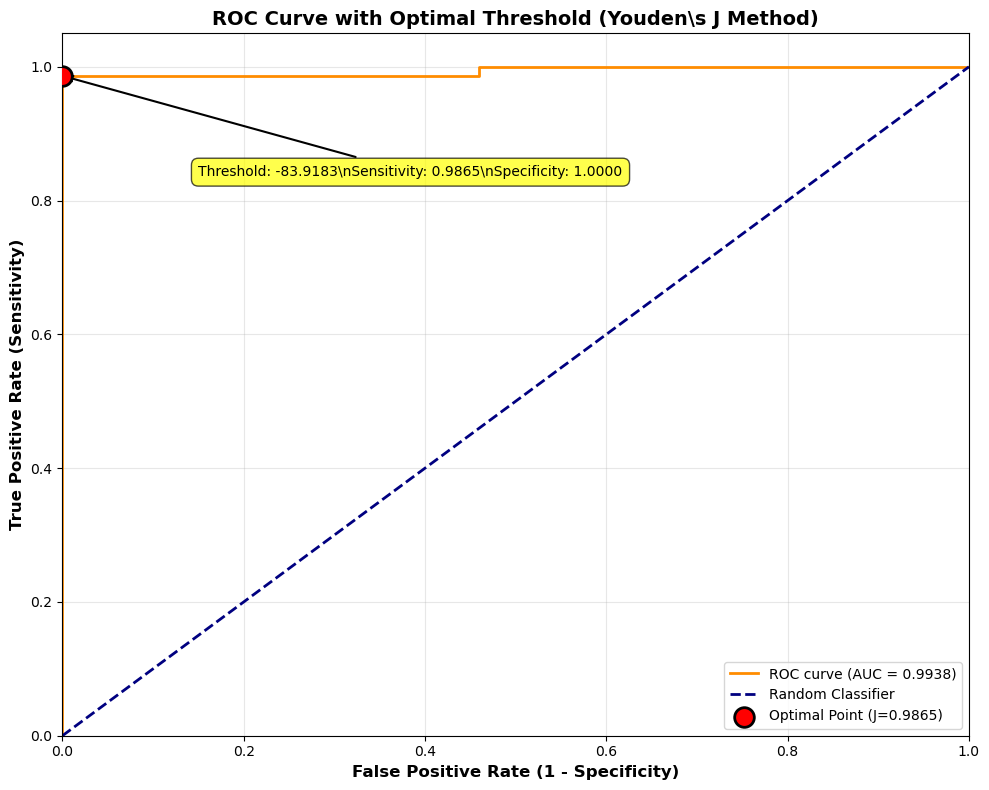


OPTIMAL ROL CUTOFF FOR DEEPINSPIRE

✓ Optimal ROL Cutoff: 83.918%
  Interpretation: Classify as 'Inadequate' if ROL < 83.918%
                 Classify as 'Adequate' if ROL ≥ 83.918%

  - Sensitivity: 0.9865
  - Specificity: 1.0000
  - Youden's J: 0.9865
  - AUC: 0.9938


Recommended ROL Cutoff: 83.918%


In [8]:
# Example: Calculate optimal ROL cutoff
# Make sure models are loaded first (see section 2)

test_folder = ROL_cal_image_folder

# Calculate optimal ROL cutoff
optimal_results = calculate_optimal_rol_cutoff(
    test_folder=test_folder,
    rib_model=rib_model,
    lung_model=lung_model,
    device=device
)

# The optimal cutoff is stored in:
print(f"\n\nRecommended ROL Cutoff: {optimal_results['optimal_rol_cutoff']:.3f}%")

## 5. Evaluation Function

In [26]:
def dice_cal(y_true, y_pred):
    """Calculate Dice Similarity Coefficient between two binary masks."""
    intersection = np.sum(np.logical_and(y_true, y_pred).astype(float))
    if (np.sum(y_true) == 0) and (np.sum(y_pred) == 0):
        return 1.0
    if (np.sum(y_true) + np.sum(y_pred)) == 0:
        return 0.0
    return (2 * intersection) / (np.sum(y_true) + np.sum(y_pred))


def evaluate_both_approaches(test_folder, rib_model, lung_model, classification_model, device, 
                            rol_cutoff=85.698):
    """
    Comprehensive evaluation of both DeepInspire and Classification approaches on test dataset.
    
    Args:
        test_folder: Path to test folder containing 'full' and 'not full' subfolders
        rib_model: Trained rib segmentation model
        lung_model: Trained lung segmentation model
        classification_model: Trained classification model
        device: torch device (cpu or cuda)
        rol_cutoff: ROL threshold for DeepInspire (default: 85.698)
    
    Returns:
        results: Dictionary containing all evaluation metrics and visualizations
    """
    print("=" * 80)
    print("COMPREHENSIVE EVALUATION OF BOTH APPROACHES")
    print("=" * 80)
    
    # Load test images from new folder structure
    full_folder = os.path.join(test_folder, 'full', 'image')
    not_full_folder = os.path.join(test_folder, 'not full', 'image')
    
    full_images = [os.path.join(full_folder, f) for f in os.listdir(full_folder) if f.endswith(('.png', '.jpg', '.jpeg'))]
    not_full_images = [os.path.join(not_full_folder, f) for f in os.listdir(not_full_folder) if f.endswith(('.png', '.jpg', '.jpeg'))]
    
    print(f"\nTest Dataset:")
    print(f"  - Adequate inspiration (full): {len(full_images)} images")
    print(f"  - Inadequate inspiration (not full): {len(not_full_images)} images")
    print(f"  - Total: {len(full_images) + len(not_full_images)} images")
    
    # Check if segmentation masks are available for DSC calculation
    calculate_dsc = False
    if test_folder is not None:
        seg_image_folder_full = os.path.join(test_folder, 'full/image')
        rib_mask_folder_full = os.path.join(test_folder, 'full/mask/rib')
        lung_mask_folder_full = os.path.join(test_folder, 'full/mask/lung')
        seg_image_folder_not_full = os.path.join(test_folder, 'not full/image')
        rib_mask_folder_not_full = os.path.join(test_folder, 'not full/mask/rib')
        lung_mask_folder_not_full = os.path.join(test_folder, 'not full/mask/lung')
        print("\nChecking for segmentation masks for DSC calculation...")
        print(f"  - Segmentation images folder: {seg_image_folder_full}")
        print(f"  - Rib masks folder: {rib_mask_folder_full}")
        print(f"  - Lung masks folder: {lung_mask_folder_full}")
        print(f"  - Segmentation images folder: {seg_image_folder_not_full}")
        print(f"  - Rib masks folder: {rib_mask_folder_not_full}")
        print(f"  - Lung masks folder: {lung_mask_folder_not_full}")
        
        if os.path.exists(seg_image_folder_full) and os.path.exists(rib_mask_folder_full) and os.path.exists(lung_mask_folder_full) and os.path.exists(seg_image_folder_not_full) and os.path.exists(rib_mask_folder_not_full) and os.path.exists(lung_mask_folder_not_full):
            calculate_dsc = True
            print(f"\n✓ Segmentation masks found - DSC will be calculated")
            
            # Load segmentation test images
            seg_test_images_full = sorted([f for f in os.listdir(seg_image_folder_full) if f.endswith(('.png', '.jpg', '.jpeg'))])
            seg_test_images_not_full = sorted([f for f in os.listdir(seg_image_folder_not_full) if f.endswith(('.png', '.jpg', '.jpeg'))])
            # Storage for DSC scores
            rib_dsc_bg = []  # Class 0: Background
            rib_dsc_lt = []  # Class 1: Left rib
            rib_dsc_rt = []  # Class 2: Right rib
            lung_dsc_bg = []  # Class 0: Background
            lung_dsc_lt = []  # Class 1: Left lung
            lung_dsc_rt = []  # Class 2: Right lung
        else:
            print(f"\n⚠ Segmentation masks not found - DSC calculation skipped")
    
    # Initialize storage
    results_data = []
    
    # Ground truth labels
    y_true = [0] * len(full_images) + [1] * len(not_full_images)  # 1=Inadequate (Positive), 0=Adequate (Negative)
    all_images = full_images + not_full_images
    
    # Storage for predictions
    y_pred_deepinspire = []
    y_pred_classification = []
    y_score_deepinspire = []  # ROL values (higher = more adequate, lower = more inadequate)
    y_score_classification = []  # Confidence scores
    
    # Storage for processing times
    time_deepinspire = []
    time_classification = []
    
    print("\nProcessing images...")
    
    # Preprocessing function for segmentation
    def preprocess_for_segmentation(img, device):
        preprocessing_fn = smp.encoders.get_preprocessing_fn(ENCODER, 'imagenet')
        img = preprocessing_fn(img)
        image = img.astype(np.float64)
        image = np.transpose(image, (2, 0, 1))
        img_input = np.expand_dims(image, 0)
        img_input = np_to_torch(img_input).to(device)
        return img_input
    
    # Calculate DSC on segmentation test set if available
    if calculate_dsc:
        print("\nCalculating DSC for segmentation models...")
        SIZE_X = 512
        SIZE_Y = 512
        
        for img_name in tqdm(seg_test_images_full, desc="Processing segmentation test set (full)"):
            try:
                # Load image
                img_path = os.path.join(seg_image_folder_full, img_name)
                image = cv2.imread(img_path, 1)
                image = cv2.resize(image, (SIZE_Y, SIZE_X), interpolation=cv2.INTER_NEAREST)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = image / 255.0
                image = image.astype(np.float64)
                
                # Get base name without extension for mask matching
                base_name = os.path.splitext(img_name)[0]
                
                # Load rib mask (.tiff format)
                rib_mask_path = os.path.join(rib_mask_folder_full, 'rib_' + base_name + '.tiff')
                rib_mask = np.array(tiff.imread(rib_mask_path))
                
                # Load lung mask (.tiff format)
                lung_mask_path = os.path.join(lung_mask_folder_full, 'lung_' + base_name + '.tiff')
                lung_mask = np.array(tiff.imread(lung_mask_path))
                
                # Preprocess image for model
                img_input = preprocess_for_segmentation(image.copy(), device)
                
                # Predict with rib model
                with torch.no_grad():
                    rib_pred = rib_model(img_input)
                rib_pred_np = torch.squeeze(rib_pred.detach().cpu()).numpy()
                rib_pred_argmax = np.argmax(rib_pred_np, axis=0)
                
                # Predict with lung model
                with torch.no_grad():
                    lung_pred = lung_model(img_input)
                lung_pred_np = torch.squeeze(lung_pred.detach().cpu()).numpy()
                lung_pred_argmax = np.argmax(lung_pred_np, axis=0)
                
                # Calculate DSC for rib segmentation (classes: 0=BG, 1=Lt_rib, 2=Rt_rib)
                rib_dsc_bg.append(dice_cal(rib_mask[:,:,0], rib_pred_argmax == 0))
                rib_dsc_lt.append(dice_cal(rib_mask[:,:,1], rib_pred_argmax == 1))
                rib_dsc_rt.append(dice_cal(rib_mask[:,:,2], rib_pred_argmax == 2))
                
                # Calculate DSC for lung segmentation (classes: 0=BG, 1=Lt_lung, 2=Rt_lung)
                lung_dsc_bg.append(dice_cal(lung_mask[:,:,0], lung_pred_argmax == 0))
                lung_dsc_lt.append(dice_cal(lung_mask[:,:,1], lung_pred_argmax == 1))
                lung_dsc_rt.append(dice_cal(lung_mask[:,:,2], lung_pred_argmax == 2))
                
            except Exception as e:
                print(f"Error processing {img_name}: {e}")
                continue
        
        for img_name in tqdm(seg_test_images_not_full, desc="Processing segmentation test set (not full)"):
            try:
                # Load image
                img_path = os.path.join(seg_image_folder_not_full, img_name)
                image = cv2.imread(img_path, 1)
                image = cv2.resize(image, (SIZE_Y, SIZE_X), interpolation=cv2.INTER_NEAREST)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = image / 255.0
                image = image.astype(np.float64)
                
                # Get base name without extension for mask matching
                base_name = os.path.splitext(img_name)[0]
                
                # Load rib mask (.tiff format)
                rib_mask_path = os.path.join(rib_mask_folder_not_full, 'rib_' + base_name + '.tiff')
                rib_mask = np.array(tiff.imread(rib_mask_path))
                
                # Load lung mask (.tiff format)
                lung_mask_path = os.path.join(lung_mask_folder_not_full, 'lung_' + base_name + '.tiff')
                lung_mask = np.array(tiff.imread(lung_mask_path))
                
                # Preprocess image for model
                img_input = preprocess_for_segmentation(image.copy(), device)
                
                # Predict with rib model
                with torch.no_grad():
                    rib_pred = rib_model(img_input)
                rib_pred_np = torch.squeeze(rib_pred.detach().cpu()).numpy()
                rib_pred_argmax = np.argmax(rib_pred_np, axis=0)
                
                # Predict with lung model
                with torch.no_grad():
                    lung_pred = lung_model(img_input)
                lung_pred_np = torch.squeeze(lung_pred.detach().cpu()).numpy()
                lung_pred_argmax = np.argmax(lung_pred_np, axis=0)
                
                # Calculate DSC for rib segmentation (classes: 0=BG, 1=Lt_rib, 2=Rt_rib)
                rib_dsc_bg.append(dice_cal(rib_mask[:,:,0], rib_pred_argmax == 0))
                rib_dsc_lt.append(dice_cal(rib_mask[:,:,1], rib_pred_argmax == 1))
                rib_dsc_rt.append(dice_cal(rib_mask[:,:,2], rib_pred_argmax == 2))
                
                # Calculate DSC for lung segmentation (classes: 0=BG, 1=Lt_lung, 2=Rt_lung)
                lung_dsc_bg.append(dice_cal(lung_mask[:,:,0], lung_pred_argmax == 0))
                lung_dsc_lt.append(dice_cal(lung_mask[:,:,1], lung_pred_argmax == 1))
                lung_dsc_rt.append(dice_cal(lung_mask[:,:,2], lung_pred_argmax == 2))
                
            except Exception as e:
                print(f"Error processing {img_name}: {e}")
                continue

        # Calculate mean DSC scores
        print("\n" + "=" * 80)
        print("SEGMENTATION MODEL PERFORMANCE (DICE SIMILARITY COEFFICIENT)")
        print("=" * 80)
        
        print("\n📊 Rib Segmentation DSC:")
        print(f"  Class 0 (Background): {np.mean(rib_dsc_bg):.4f} ± {np.std(rib_dsc_bg):.4f}")
        print(f"  Class 1 (Left Rib):   {np.mean(rib_dsc_lt):.4f} ± {np.std(rib_dsc_lt):.4f}")
        print(f"  Class 2 (Right Rib):  {np.mean(rib_dsc_rt):.4f} ± {np.std(rib_dsc_rt):.4f}")
        print(f"  Mean (All Classes):   {np.mean([np.mean(rib_dsc_bg), np.mean(rib_dsc_lt), np.mean(rib_dsc_rt)]):.4f}")
        print(f"  Mean (Foreground):    {np.mean([np.mean(rib_dsc_lt), np.mean(rib_dsc_rt)]):.4f}")
        
        print("\n📊 Lung Segmentation DSC:")
        print(f"  Class 0 (Background): {np.mean(lung_dsc_bg):.4f} ± {np.std(lung_dsc_bg):.4f}")
        print(f"  Class 1 (Left Lung):  {np.mean(lung_dsc_lt):.4f} ± {np.std(lung_dsc_lt):.4f}")
        print(f"  Class 2 (Right Lung): {np.mean(lung_dsc_rt):.4f} ± {np.std(lung_dsc_rt):.4f}")
        print(f"  Mean (All Classes):   {np.mean([np.mean(lung_dsc_bg), np.mean(lung_dsc_lt), np.mean(lung_dsc_rt)]):.4f}")
        print(f"  Mean (Foreground):    {np.mean([np.mean(lung_dsc_lt), np.mean(lung_dsc_rt)]):.4f}")
    
    # Process each image for classification evaluation
    print("\n" + "=" * 80)
    print("CLASSIFICATION EVALUATION")
    print("=" * 80)
    
    for idx, image_path in enumerate(tqdm(all_images, desc="Processing classification test set")):
        true_label = y_true[idx]
        true_label_str = "Inadequate" if true_label == 1 else "Adequate"
        
        try:
            # Load image
            SIZE_X = 512
            SIZE_Y = 512
            original_image = cv2.imread(image_path, 1)
            original_image = cv2.resize(original_image, (SIZE_Y, SIZE_X), interpolation=cv2.INTER_NEAREST)
            original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
            original_image = original_image / 255
            original_image = original_image.astype(np.float64)
            
            # ============================
            # DeepInspire Approach
            # ============================
            start_time_di = time.time()
            
            img_input = preprocess_for_segmentation(original_image.copy(), device)
            
            # Predict with rib model
            with torch.no_grad():
                r_y_pred = rib_model(img_input)
            r_y_pred_np = torch_to_np(r_y_pred)
            r_y_pred_argmax = np.argmax(r_y_pred_np, axis=0)
            
            # Predict with lung model
            with torch.no_grad():
                l_y_pred = lung_model(img_input)
            l_y_pred_np = torch_to_np(l_y_pred)
            l_y_pred_argmax = np.argmax(l_y_pred_np, axis=0)
            
            # Calculate ROL
            l_y_pred_argmax[l_y_pred_argmax > 0] = 1
            r_y_pred_argmax[r_y_pred_argmax > 0] = 2
            r_l_y_pred_argmax = r_y_pred_argmax + l_y_pred_argmax
            
            union = np.count_nonzero(r_l_y_pred_argmax == 2) + np.count_nonzero(r_l_y_pred_argmax == 3)
            intersec = np.count_nonzero(r_l_y_pred_argmax == 3)
            
            if union > 0:
                rol = (intersec / union) * 100
            else:
                rol = 0
            
            pred_deepinspire = 0 if rol > rol_cutoff else 1  # 0=Adequate, 1=Inadequate (Positive)
            y_pred_deepinspire.append(pred_deepinspire)
            # For ROC: use inverse of ROL (100-rol) since higher score should indicate positive class (Inadequate)
            y_score_deepinspire.append(100 - rol)
            
            end_time_di = time.time()
            time_deepinspire.append(end_time_di - start_time_di)
            
            # ============================
            # Classification Approach
            # ============================
            start_time_clf = time.time()
            
            img, _ = load_image(image_path)
            input_tensor = img.unsqueeze(0).to(device)
            
            with torch.no_grad():
                output = classification_model(input_tensor)
                predicted_class = torch.argmax(output, dim=1).item()
                confidence = torch.softmax(output, dim=1)[0, predicted_class].item()
            
            # Convert to our label scheme: model class 0=Adequate, 1=Inadequate
            # Our evaluation: 1=Inadequate (Positive), 0=Adequate (Negative)
            pred_classification = 1 if predicted_class == 1 else 0
            y_pred_classification.append(pred_classification)
            
            # For ROC, we need probability of positive class (Inadequate=1)
            prob_inadequate = torch.softmax(output, dim=1)[0, 1].item()  # Probability of class 1 (Inadequate)
            y_score_classification.append(prob_inadequate)
            
            end_time_clf = time.time()
            time_classification.append(end_time_clf - start_time_clf)
            
            # Store results
            results_data.append({
                'image': os.path.basename(image_path),
                'true_label': true_label_str,
                'deepinspire_pred': "Inadequate" if pred_deepinspire == 1 else "Adequate",
                'deepinspire_rol': rol,
                'classification_pred': "Inadequate" if pred_classification == 1 else "Adequate",
                'classification_conf': prob_inadequate,
                'deepinspire_correct': pred_deepinspire == true_label,
                'classification_correct': pred_classification == true_label
            })
            
        except Exception as e:
            print(f"Error processing {image_path}: {e}")
            continue
    
    # Create results DataFrame
    results_df = pd.DataFrame(results_data)
    
    # ============================
    # Confusion Matrices
    # ============================
    print("\n" + "=" * 80)
    print("CONFUSION MATRICES")
    print("=" * 80)
    
    cm_deepinspire = confusion_matrix(y_true, y_pred_deepinspire)
    cm_classification = confusion_matrix(y_true, y_pred_classification)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=300)
    
    # DeepInspire confusion matrix
    sns.heatmap(cm_deepinspire, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Adequate', 'Inadequate'],
                yticklabels=['Adequate', 'Inadequate'],
                ax=axes[0], cbar_kws={'label': 'Count'})
    axes[0].set_title('DeepInspire (ROL-based)\nConfusion Matrix', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('True Label', fontsize=12)
    axes[0].set_xlabel('Predicted Label', fontsize=12)
    
    # Classification confusion matrix
    sns.heatmap(cm_classification, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Adequate', 'Inadequate'],
                yticklabels=['Adequate', 'Inadequate'],
                ax=axes[1], cbar_kws={'label': 'Count'})
    axes[1].set_title('Classification CNN\nConfusion Matrix', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('True Label', fontsize=12)
    axes[1].set_xlabel('Predicted Label', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # ============================
    # Calculate Metrics
    # ============================
    print("\n" + "=" * 80)
    print("PERFORMANCE METRICS")
    print("=" * 80)
    
    def calculate_metrics(y_true, y_pred, cm):
        tn, fp, fn, tp = cm.ravel()
        
        accuracy = accuracy_score(y_true, y_pred)
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # Recall, TPR - detects Inadequate (Positive)
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR - detects Adequate (Negative)
        precision = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        
        return {
            'Accuracy': accuracy,
            'Sensitivity (Recall)': sensitivity,
            'Specificity': specificity,
            'Precision': precision,
            'F1 Score': f1,
            'TP': tp,
            'TN': tn,
            'FP': fp,
            'FN': fn
        }
    
    metrics_deepinspire = calculate_metrics(y_true, y_pred_deepinspire, cm_deepinspire)
    metrics_classification = calculate_metrics(y_true, y_pred_classification, cm_classification)
    
    # Create metrics comparison table
    metrics_df = pd.DataFrame({
        'Metric': ['Accuracy', 'Sensitivity (Recall)', 'Specificity', 'Precision', 'F1 Score'],
        'DeepInspire': [
            f"{metrics_deepinspire['Accuracy']:.4f}",
            f"{metrics_deepinspire['Sensitivity (Recall)']:.4f}",
            f"{metrics_deepinspire['Specificity']:.4f}",
            f"{metrics_deepinspire['Precision']:.4f}",
            f"{metrics_deepinspire['F1 Score']:.4f}"
        ],
        'Classification': [
            f"{metrics_classification['Accuracy']:.4f}",
            f"{metrics_classification['Sensitivity (Recall)']:.4f}",
            f"{metrics_classification['Specificity']:.4f}",
            f"{metrics_classification['Precision']:.4f}",
            f"{metrics_classification['F1 Score']:.4f}"
        ]
    })
    
    print("\nPerformance Metrics Comparison:")
    print(metrics_df.to_string(index=False))
    
    # ============================
    # ROC Curves
    # ============================
    print("\n" + "=" * 80)
    print("ROC CURVES")
    print("=" * 80)
    
    # For DeepInspire, scores are already inverted (100-ROL), just normalize to 0-1 range
    # For DeepInspire, normalize ROL to 0-1 range for ROC
    y_score_deepinspire_norm = np.array(y_score_deepinspire) / 100.0
    
    fpr_deepinspire, tpr_deepinspire, _ = roc_curve(y_true, y_score_deepinspire_norm)
    fpr_classification, tpr_classification, _ = roc_curve(y_true, y_score_classification)
    
    auc_deepinspire = auc(fpr_deepinspire, tpr_deepinspire)
    auc_classification = auc(fpr_classification, tpr_classification)
    
    # ============================
    # Bootstrap AUC Confidence Intervals
    # ============================
    def bootstrap_auc(y_true, y_scores, n_bootstraps=10**5, confidence_level=0.95, random_state=42):
        """
        Calculate bootstrap confidence interval for AUC.
        
        Args:
            y_true: True labels
            y_scores: Prediction scores
            n_bootstraps: Number of bootstrap iterations
            confidence_level: Confidence level (default 0.95 for 95% CI)
            random_state: Random seed for reproducibility
            
        Returns:
            auc_value: Original AUC
            ci_lower: Lower bound of CI
            ci_upper: Upper bound of CI
        """
        np.random.seed(random_state)
        
        y_true = np.array(y_true)
        y_scores = np.array(y_scores)
        n_samples = len(y_true)
        
        # Calculate original AUC
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        auc_value = auc(fpr, tpr)
        
        # Bootstrap
        bootstrapped_aucs = []
        for i in range(n_bootstraps):
            # Resample with replacement
            indices = np.random.choice(n_samples, size=n_samples, replace=True)
            
            # Skip if all samples are same class
            if len(np.unique(y_true[indices])) < 2:
                continue
                
            # Calculate AUC for this bootstrap sample
            fpr_boot, tpr_boot, _ = roc_curve(y_true[indices], y_scores[indices])
            auc_boot = auc(fpr_boot, tpr_boot)
            bootstrapped_aucs.append(auc_boot)
        
        # Calculate confidence intervals
        alpha = 1 - confidence_level
        ci_lower = np.percentile(bootstrapped_aucs, 100 * alpha / 2)
        ci_upper = np.percentile(bootstrapped_aucs, 100 * (1 - alpha / 2))
        
        return auc_value, ci_lower, ci_upper
    
    # Calculate AUC with 95% CI for both methods
    auc_di, auc_di_lower, auc_di_upper = bootstrap_auc(y_true, y_score_deepinspire_norm)
    auc_clf, auc_clf_lower, auc_clf_upper = bootstrap_auc(y_true, y_score_classification)
    
    # Plot ROC curves
    roc_pack = (fpr_deepinspire, tpr_deepinspire, auc_deepinspire,
                fpr_classification, tpr_classification, auc_classification)
    fig, ax = plt.subplots(1, 1, figsize=(10, 8), dpi=300)
    
    ax.plot(fpr_deepinspire, tpr_deepinspire, 'black', linestyle='-', linewidth=2,
            label=f'DeepInspire\nAUC: {auc_deepinspire:.2f} ({auc_di_lower:.2f}, {auc_di_upper:.2f})')
    ax.plot(fpr_classification, tpr_classification, 'black', linestyle='--',linewidth=2,
            label=f'Classification CNN\nAUC: {auc_classification:.2f} ({auc_clf_lower:.2f}, {auc_clf_upper:.2f})')
    # ax.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random Classifier (AUC = 0.5000)')
    
    ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    ax.set_title('ROC Curves Comparison', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=11)
    # ax.grid(True, alpha=0.3)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    
    # Remove top and right spines (box)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nAUC Scores with 95% Confidence Intervals:")
    print(f"  - DeepInspire: {auc_di:.4f} [{auc_di_lower:.4f}, {auc_di_upper:.4f}]")
    print(f"  - Classification CNN: {auc_clf:.4f} [{auc_clf_lower:.4f}, {auc_clf_upper:.4f}]")
    print(f"  - Difference: {abs(auc_deepinspire - auc_classification):.4f}")
    
    # ============================
    # Statistical Test (McNemar's Test)
    # ============================
    print("\n" + "=" * 80)
    print("STATISTICAL COMPARISON")
    print("=" * 80)
    
    # Create contingency table for McNemar's test
    both_correct = sum((np.array(y_pred_deepinspire) == np.array(y_true)) & 
                      (np.array(y_pred_classification) == np.array(y_true)))
    deepinspire_only = sum((np.array(y_pred_deepinspire) == np.array(y_true)) & 
                          (np.array(y_pred_classification) != np.array(y_true)))
    classification_only = sum((np.array(y_pred_deepinspire) != np.array(y_true)) & 
                             (np.array(y_pred_classification) == np.array(y_true)))
    both_incorrect = sum((np.array(y_pred_deepinspire) != np.array(y_true)) & 
                        (np.array(y_pred_classification) != np.array(y_true)))
    
    print("\nMcNemar's Test Contingency Table:")
    print(f"  Both Correct: {both_correct}")
    print(f"  DeepInspire Correct Only: {deepinspire_only}")
    print(f"  Classification Correct Only: {classification_only}")
    print(f"  Both Incorrect: {both_incorrect}")
    
    # Perform McNemar's test
    b = deepinspire_only
    c = classification_only
    n = b + c
    
    if n > 0:
        # Exact binomial test
        p_value = 2 * min(stats.binom.cdf(min(b, c), n, 0.5), 1 - stats.binom.cdf(min(b, c) - 1, n, 0.5))
        print(f"\nMcNemar's Test Results:")
        print(f"  Discordant pairs: {n} (DeepInspire only: {b}, Classification only: {c})")
        print(f"  P-value: {p_value:.4f}")
        
        if p_value < 0.05:
            print(f"  Conclusion: Statistically significant difference (p < 0.05)")
            if b > c:
                print(f"  DeepInspire performs significantly better")
            else:
                print(f"  Classification CNN performs significantly better")
        else:
            print(f"  Conclusion: No statistically significant difference (p >= 0.05)")
    else:
        print("\nMcNemar's Test: Cannot be performed (no discordant pairs)")
        p_value = 1.0
    
    # ============================
    # 95% Confidence Intervals
    # ============================
    print("\n" + "=" * 80)
    print("95% CONFIDENCE INTERVALS")
    print("=" * 80)
    
    def wilson_score_interval(successes, n, confidence=0.95):
        """Calculate Wilson score confidence interval."""
        if n == 0:
            return 0, 0, 0
        
        p_hat = successes / n
        z = stats.norm.ppf((1 + confidence) / 2)
        
        denominator = 1 + z**2 / n
        center = (p_hat + z**2 / (2 * n)) / denominator
        margin = z * np.sqrt((p_hat * (1 - p_hat) / n + z**2 / (4 * n**2))) / denominator
        
        lower = center - margin
        upper = center + margin
        
        return p_hat, lower, upper
    
    n_total = len(y_true)
    
    # Accuracy CI
    acc_di, acc_di_lower, acc_di_upper = wilson_score_interval(
        sum(np.array(y_pred_deepinspire) == np.array(y_true)), n_total)
    acc_clf, acc_clf_lower, acc_clf_upper = wilson_score_interval(
        sum(np.array(y_pred_classification) == np.array(y_true)), n_total)
    
    # Sensitivity CI
    n_positive = sum(y_true)
    sens_di, sens_di_lower, sens_di_upper = wilson_score_interval(
        metrics_deepinspire['TP'], n_positive)
    sens_clf, sens_clf_lower, sens_clf_upper = wilson_score_interval(
        metrics_classification['TP'], n_positive)
    
    # Specificity CI
    n_negative = n_total - n_positive
    spec_di, spec_di_lower, spec_di_upper = wilson_score_interval(
        metrics_deepinspire['TN'], n_negative)
    spec_clf, spec_clf_lower, spec_clf_upper = wilson_score_interval(
        metrics_classification['TN'], n_negative)
    
    print("\n95% Confidence Intervals (Wilson Score Method):")
    print("\nDeepInspire:")
    print(f"  Accuracy:    {acc_di:.4f} [{acc_di_lower:.4f}, {acc_di_upper:.4f}]")
    print(f"  Sensitivity: {sens_di:.4f} [{sens_di_lower:.4f}, {sens_di_upper:.4f}]")
    print(f"  Specificity: {spec_di:.4f} [{spec_di_lower:.4f}, {spec_di_upper:.4f}]")
    print(f"  AUC:         {auc_di:.4f} [{auc_di_lower:.4f}, {auc_di_upper:.4f}]  (Bootstrap)")
    
    print("\nClassification CNN:")
    print(f"  Accuracy:    {acc_clf:.4f} [{acc_clf_lower:.4f}, {acc_clf_upper:.4f}]")
    print(f"  Sensitivity: {sens_clf:.4f} [{sens_clf_lower:.4f}, {sens_clf_upper:.4f}]")
    print(f"  Specificity: {spec_clf:.4f} [{spec_clf_lower:.4f}, {spec_clf_upper:.4f}]")
    print(f"  AUC:         {auc_clf:.4f} [{auc_clf_lower:.4f}, {auc_clf_upper:.4f}]  (Bootstrap)")
    
    # ============================
    # False Positives and False Negatives Analysis
    # ============================
    print("\n" + "=" * 80)
    print("FALSE POSITIVES AND FALSE NEGATIVES ANALYSIS")
    print("=" * 80)
    
    # DeepInspire FP/FN
    fp_deepinspire = results_df[(results_df['true_label'] == 'Inadequate') & 
                                (results_df['deepinspire_pred'] == 'Adequate')]
    fn_deepinspire = results_df[(results_df['true_label'] == 'Adequate') & 
                                (results_df['deepinspire_pred'] == 'Inadequate')]
    
    # Classification FP/FN
    fp_classification = results_df[(results_df['true_label'] == 'Inadequate') & 
                                   (results_df['classification_pred'] == 'Adequate')]
    fn_classification = results_df[(results_df['true_label'] == 'Adequate') & 
                                   (results_df['classification_pred'] == 'Inadequate')]
    
    print("\nDeepInspire Errors:")
    print(f"  False Positives: {len(fp_deepinspire)}")
    if len(fp_deepinspire) > 0:
        print("  FP Images (predicted Adequate, actually Inadequate):")
        for _, row in fp_deepinspire.iterrows():
            print(f"    - {row['image']}: ROL = {row['deepinspire_rol']:.2f}%")
    
    print(f"\n  False Negatives: {len(fn_deepinspire)}")
    if len(fn_deepinspire) > 0:
        print("  FN Images (predicted Inadequate, actually Adequate):")
        for _, row in fn_deepinspire.iterrows():
            print(f"    - {row['image']}: ROL = {row['deepinspire_rol']:.2f}%")
    
    print("\nClassification CNN Errors:")
    print(f"  False Positives: {len(fp_classification)}")
    if len(fp_classification) > 0:
        print("  FP Images (predicted Adequate, actually Inadequate):")
        for _, row in fp_classification.iterrows():
            print(f"    - {row['image']}: Confidence = {row['classification_conf']:.4f}")
    
    print(f"\n  False Negatives: {len(fn_classification)}")
    if len(fn_classification) > 0:
        print("  FN Images (predicted Inadequate, actually Adequate):")
        for _, row in fn_classification.iterrows():
            print(f"    - {row['image']}: Confidence = {row['classification_conf']:.4f}")
    
    # ============================
    # Summary
    # ============================
    print("\n" + "=" * 80)
    print("EVALUATION SUMMARY")
    print("=" * 80)
    
    # Calculate timing statistics
    time_di_array = np.array(time_deepinspire)
    time_clf_array = np.array(time_classification)
    
    print(f"\nDataset: {n_total} images ({n_negative} Adequate, {n_positive} Inadequate)")
    
    print(f"\nProcessing Time Analysis:")
    print(f"  DeepInspire (Segmentation-based):")
    print(f"    - Average: {np.mean(time_di_array):.4f} seconds")
    print(f"    - Min:     {np.min(time_di_array):.4f} seconds")
    print(f"    - Max:     {np.max(time_di_array):.4f} seconds")
    print(f"    - SD:      {np.std(time_di_array):.4f} seconds")
    print(f"    - Total:   {np.sum(time_di_array):.2f} seconds")
    
    print(f"\n  Classification CNN:")
    print(f"    - Average: {np.mean(time_clf_array):.4f} seconds")
    print(f"    - Min:     {np.min(time_clf_array):.4f} seconds")
    print(f"    - Max:     {np.max(time_clf_array):.4f} seconds")
    print(f"    - SD:      {np.std(time_clf_array):.4f} seconds")
    print(f"    - Total:   {np.sum(time_clf_array):.2f} seconds")
    
    speedup = np.mean(time_di_array) / np.mean(time_clf_array)
    if speedup > 1:
        print(f"\n  → Classification CNN is {speedup:.2f}x faster than DeepInspire")
    else:
        print(f"\n  → DeepInspire is {1/speedup:.2f}x faster than Classification CNN")
    
    print(f"\nOverall Performance:")
    print(f"  DeepInspire:")
    print(f"    - Accuracy: {metrics_deepinspire['Accuracy']:.4f}")
    print(f"    - AUC: {auc_di:.4f} [{auc_di_lower:.4f}, {auc_di_upper:.4f}]")
    print(f"    - Errors: {metrics_deepinspire['FP'] + metrics_deepinspire['FN']} ({len(fp_deepinspire)} FP, {len(fn_deepinspire)} FN)")
    
    print(f"\n  Classification CNN:")
    print(f"    - Accuracy: {metrics_classification['Accuracy']:.4f}")
    print(f"    - AUC: {auc_clf:.4f} [{auc_clf_lower:.4f}, {auc_clf_upper:.4f}]")
    print(f"    - Errors: {metrics_classification['FP'] + metrics_classification['FN']} ({len(fp_classification)} FP, {len(fn_classification)} FN)")
    
    if metrics_deepinspire['Accuracy'] > metrics_classification['Accuracy']:
        print(f"\n✓ DeepInspire achieves higher accuracy (+{(metrics_deepinspire['Accuracy'] - metrics_classification['Accuracy'])*100:.2f}%)")
    elif metrics_classification['Accuracy'] > metrics_deepinspire['Accuracy']:
        print(f"\n✓ Classification CNN achieves higher accuracy (+{(metrics_classification['Accuracy'] - metrics_deepinspire['Accuracy'])*100:.2f}%)")
    else:
        print(f"\n✓ Both approaches achieve the same accuracy")
    
    # Return results dictionary
    results = {
        'results_df': results_df,
        'metrics_comparison_df': metrics_df,
        'metrics_deepinspire': metrics_deepinspire,
        'metrics_classification': metrics_classification,
        'auc_deepinspire': auc_deepinspire,
        'auc_classification': auc_classification,
        'auc_deepinspire_ci': (auc_di_lower, auc_di_upper),
        'auc_classification_ci': (auc_clf_lower, auc_clf_upper),
        'cm_deepinspire': cm_deepinspire,
        'cm_classification': cm_classification,
        'false_positives': {
            'deepinspire': fp_deepinspire,
            'classification': fp_classification
        },
        'false_negatives': {
            'deepinspire': fn_deepinspire,
            'classification': fn_classification
        }
    }
    
    # Add DSC results if calculated
    if calculate_dsc:
        results['dsc_rib'] = {
            'bg': {'mean': np.mean(rib_dsc_bg), 'std': np.std(rib_dsc_bg), 'values': rib_dsc_bg},
            'left': {'mean': np.mean(rib_dsc_lt), 'std': np.std(rib_dsc_lt), 'values': rib_dsc_lt},
            'right': {'mean': np.mean(rib_dsc_rt), 'std': np.std(rib_dsc_rt), 'values': rib_dsc_rt},
            'mean_all': np.mean([np.mean(rib_dsc_bg), np.mean(rib_dsc_lt), np.mean(rib_dsc_rt)]),
            'mean_foreground': np.mean([np.mean(rib_dsc_lt), np.mean(rib_dsc_rt)])
        }
        results['dsc_lung'] = {
            'bg': {'mean': np.mean(lung_dsc_bg), 'std': np.std(lung_dsc_bg), 'values': lung_dsc_bg},
            'left': {'mean': np.mean(lung_dsc_lt), 'std': np.std(lung_dsc_lt), 'values': lung_dsc_lt},
            'right': {'mean': np.mean(lung_dsc_rt), 'std': np.std(lung_dsc_rt), 'values': lung_dsc_rt},
            'mean_all': np.mean([np.mean(lung_dsc_bg), np.mean(lung_dsc_lt), np.mean(lung_dsc_rt)]),
            'mean_foreground': np.mean([np.mean(lung_dsc_lt), np.mean(lung_dsc_rt)])

        }
    return results, roc_pack

## 6. Run Evaluation

Run the evaluation on your test dataset. Make sure your test images are organized in the following structure:
```
test/
├── full/          (Adequate inspiration images)
|   ├──image/      (Test images)
|   └──mask/ 
|      ├── rib/    (Rib masks)
|      └── lung/   (Lung masks)
└── not full/      (Inadequate inspiration images)
    ├──image/      (Test images)
    └──mask/ 
       ├── rib/    (Rib masks)
       └── lung/   (Lung masks)
```

COMPREHENSIVE EVALUATION OF BOTH APPROACHES

Test Dataset:
  - Adequate inspiration (full): 37 images
  - Inadequate inspiration (not full): 37 images
  - Total: 74 images

Checking for segmentation masks for DSC calculation...
  - Segmentation images folder: ../2026 Dataset/test/full/image
  - Rib masks folder: ../2026 Dataset/test/full/mask/rib
  - Lung masks folder: ../2026 Dataset/test/full/mask/lung
  - Segmentation images folder: ../2026 Dataset/test/not full/image
  - Rib masks folder: ../2026 Dataset/test/not full/mask/rib
  - Lung masks folder: ../2026 Dataset/test/not full/mask/lung

✓ Segmentation masks found - DSC will be calculated

Processing images...

Calculating DSC for segmentation models...


Processing segmentation test set (not full): 100%|██████████| 37/37 [00:22<00:00,  1.63it/s]



SEGMENTATION MODEL PERFORMANCE (DICE SIMILARITY COEFFICIENT)

📊 Rib Segmentation DSC:
  Class 0 (Background): 0.9952 ± 0.0042
  Class 1 (Left Rib):   0.7406 ± 0.2684
  Class 2 (Right Rib):  0.7973 ± 0.2047
  Mean (All Classes):   0.8444
  Mean (Foreground):    0.7689

📊 Lung Segmentation DSC:
  Class 0 (Background): 0.9902 ± 0.0040
  Class 1 (Left Lung):  0.9770 ± 0.0101
  Class 2 (Right Lung): 0.9760 ± 0.0082
  Mean (All Classes):   0.9811
  Mean (Foreground):    0.9765

CLASSIFICATION EVALUATION


Processing classification test set: 100%|██████████| 74/74 [00:57<00:00,  1.29it/s]



CONFUSION MATRICES


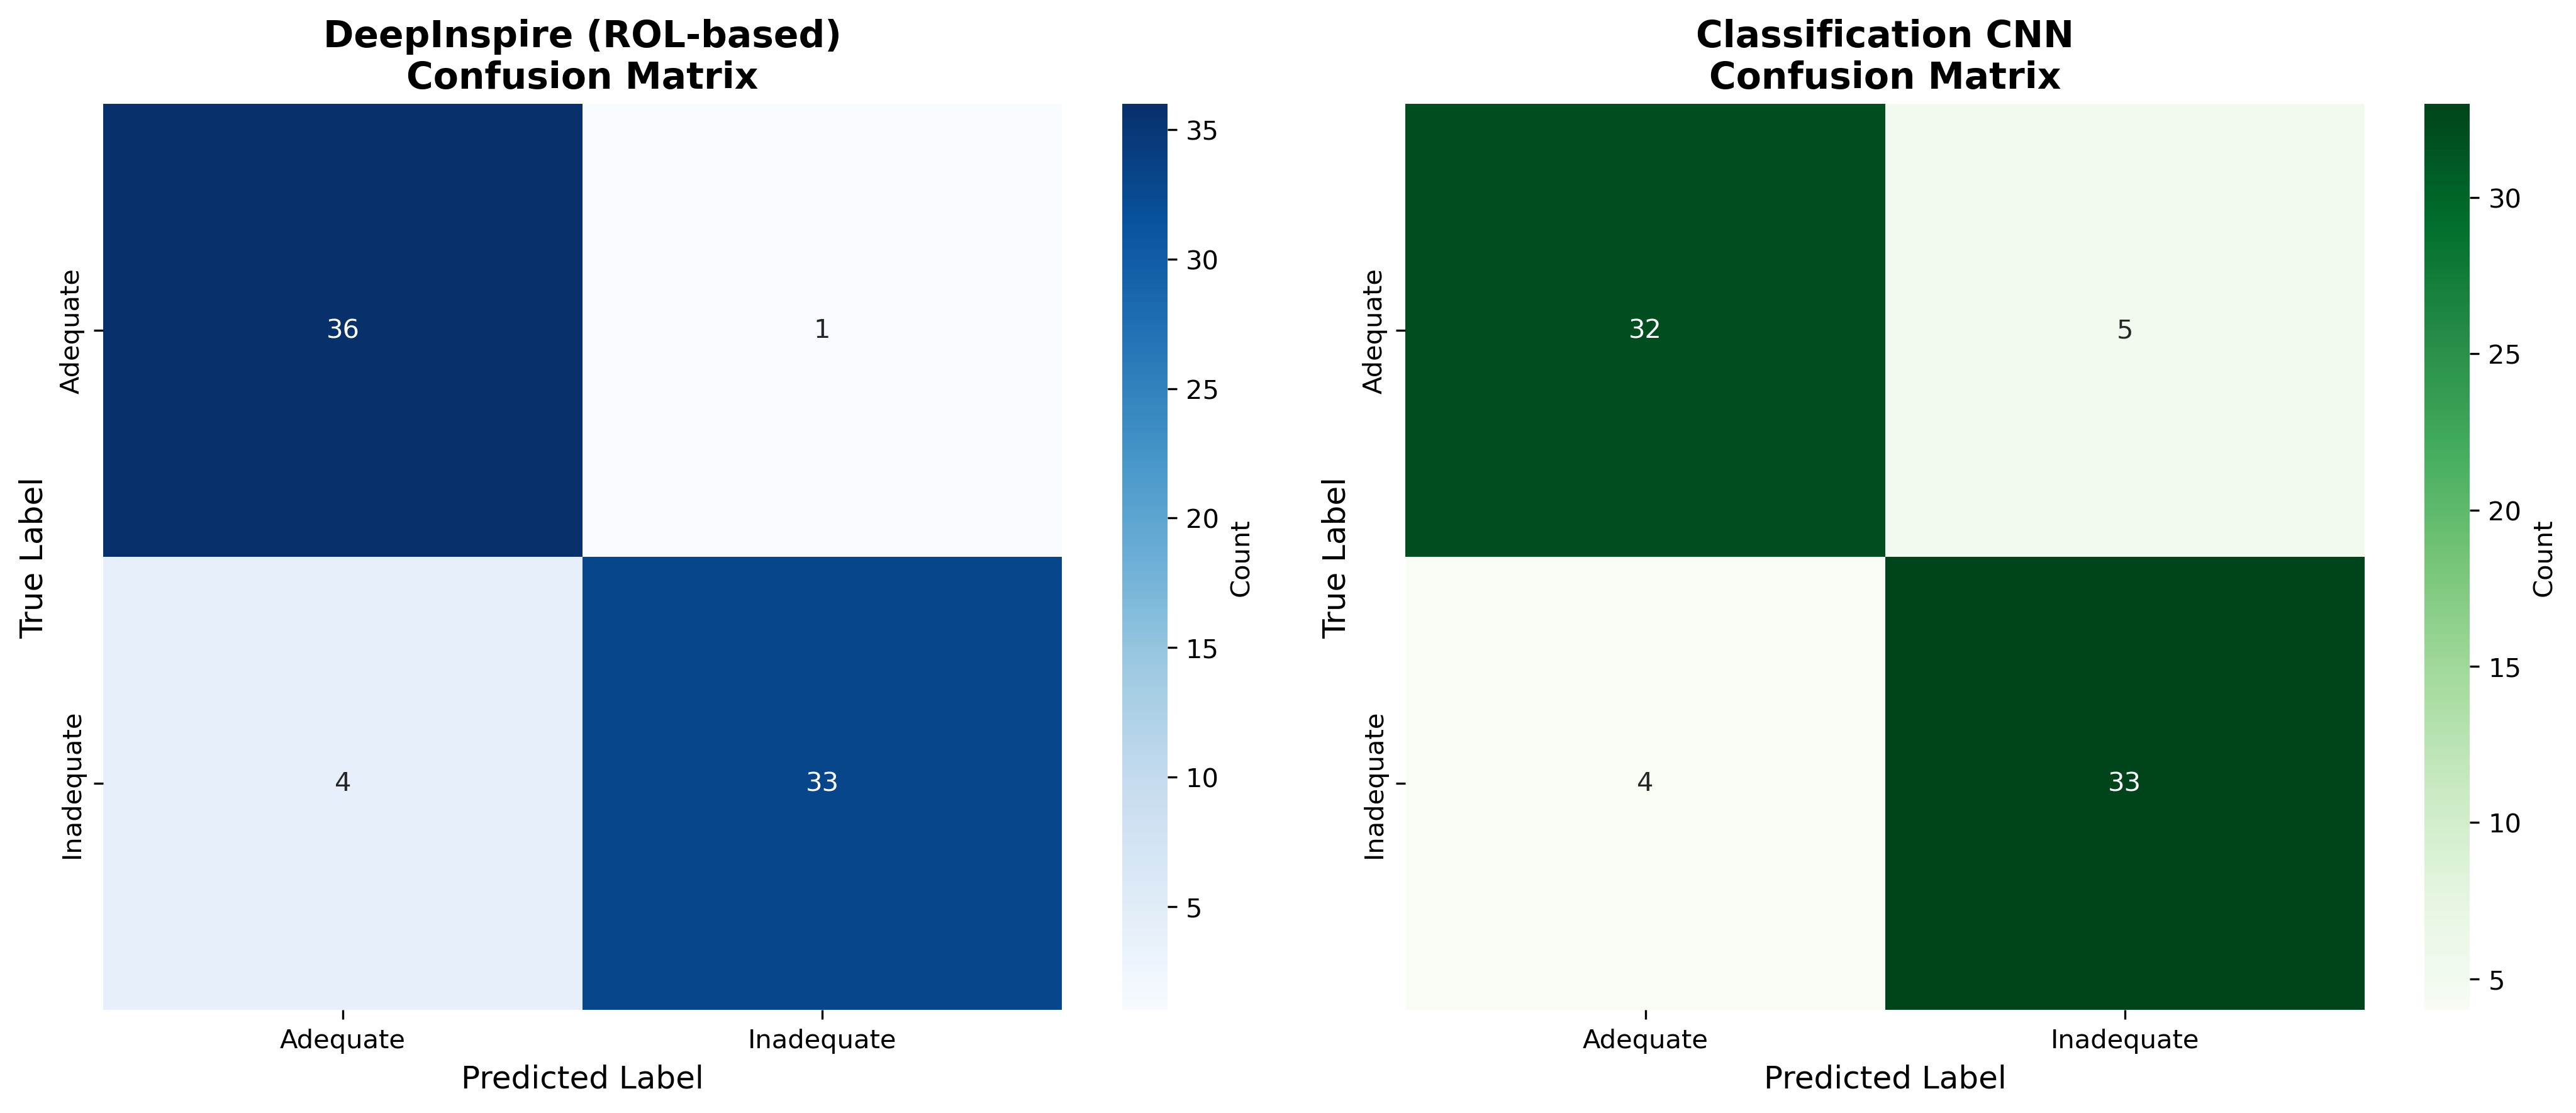


PERFORMANCE METRICS

Performance Metrics Comparison:
              Metric DeepInspire Classification
            Accuracy      0.9324         0.8784
Sensitivity (Recall)      0.8919         0.8919
         Specificity      0.9730         0.8649
           Precision      0.9706         0.8684
            F1 Score      0.9296         0.8800

ROC CURVES


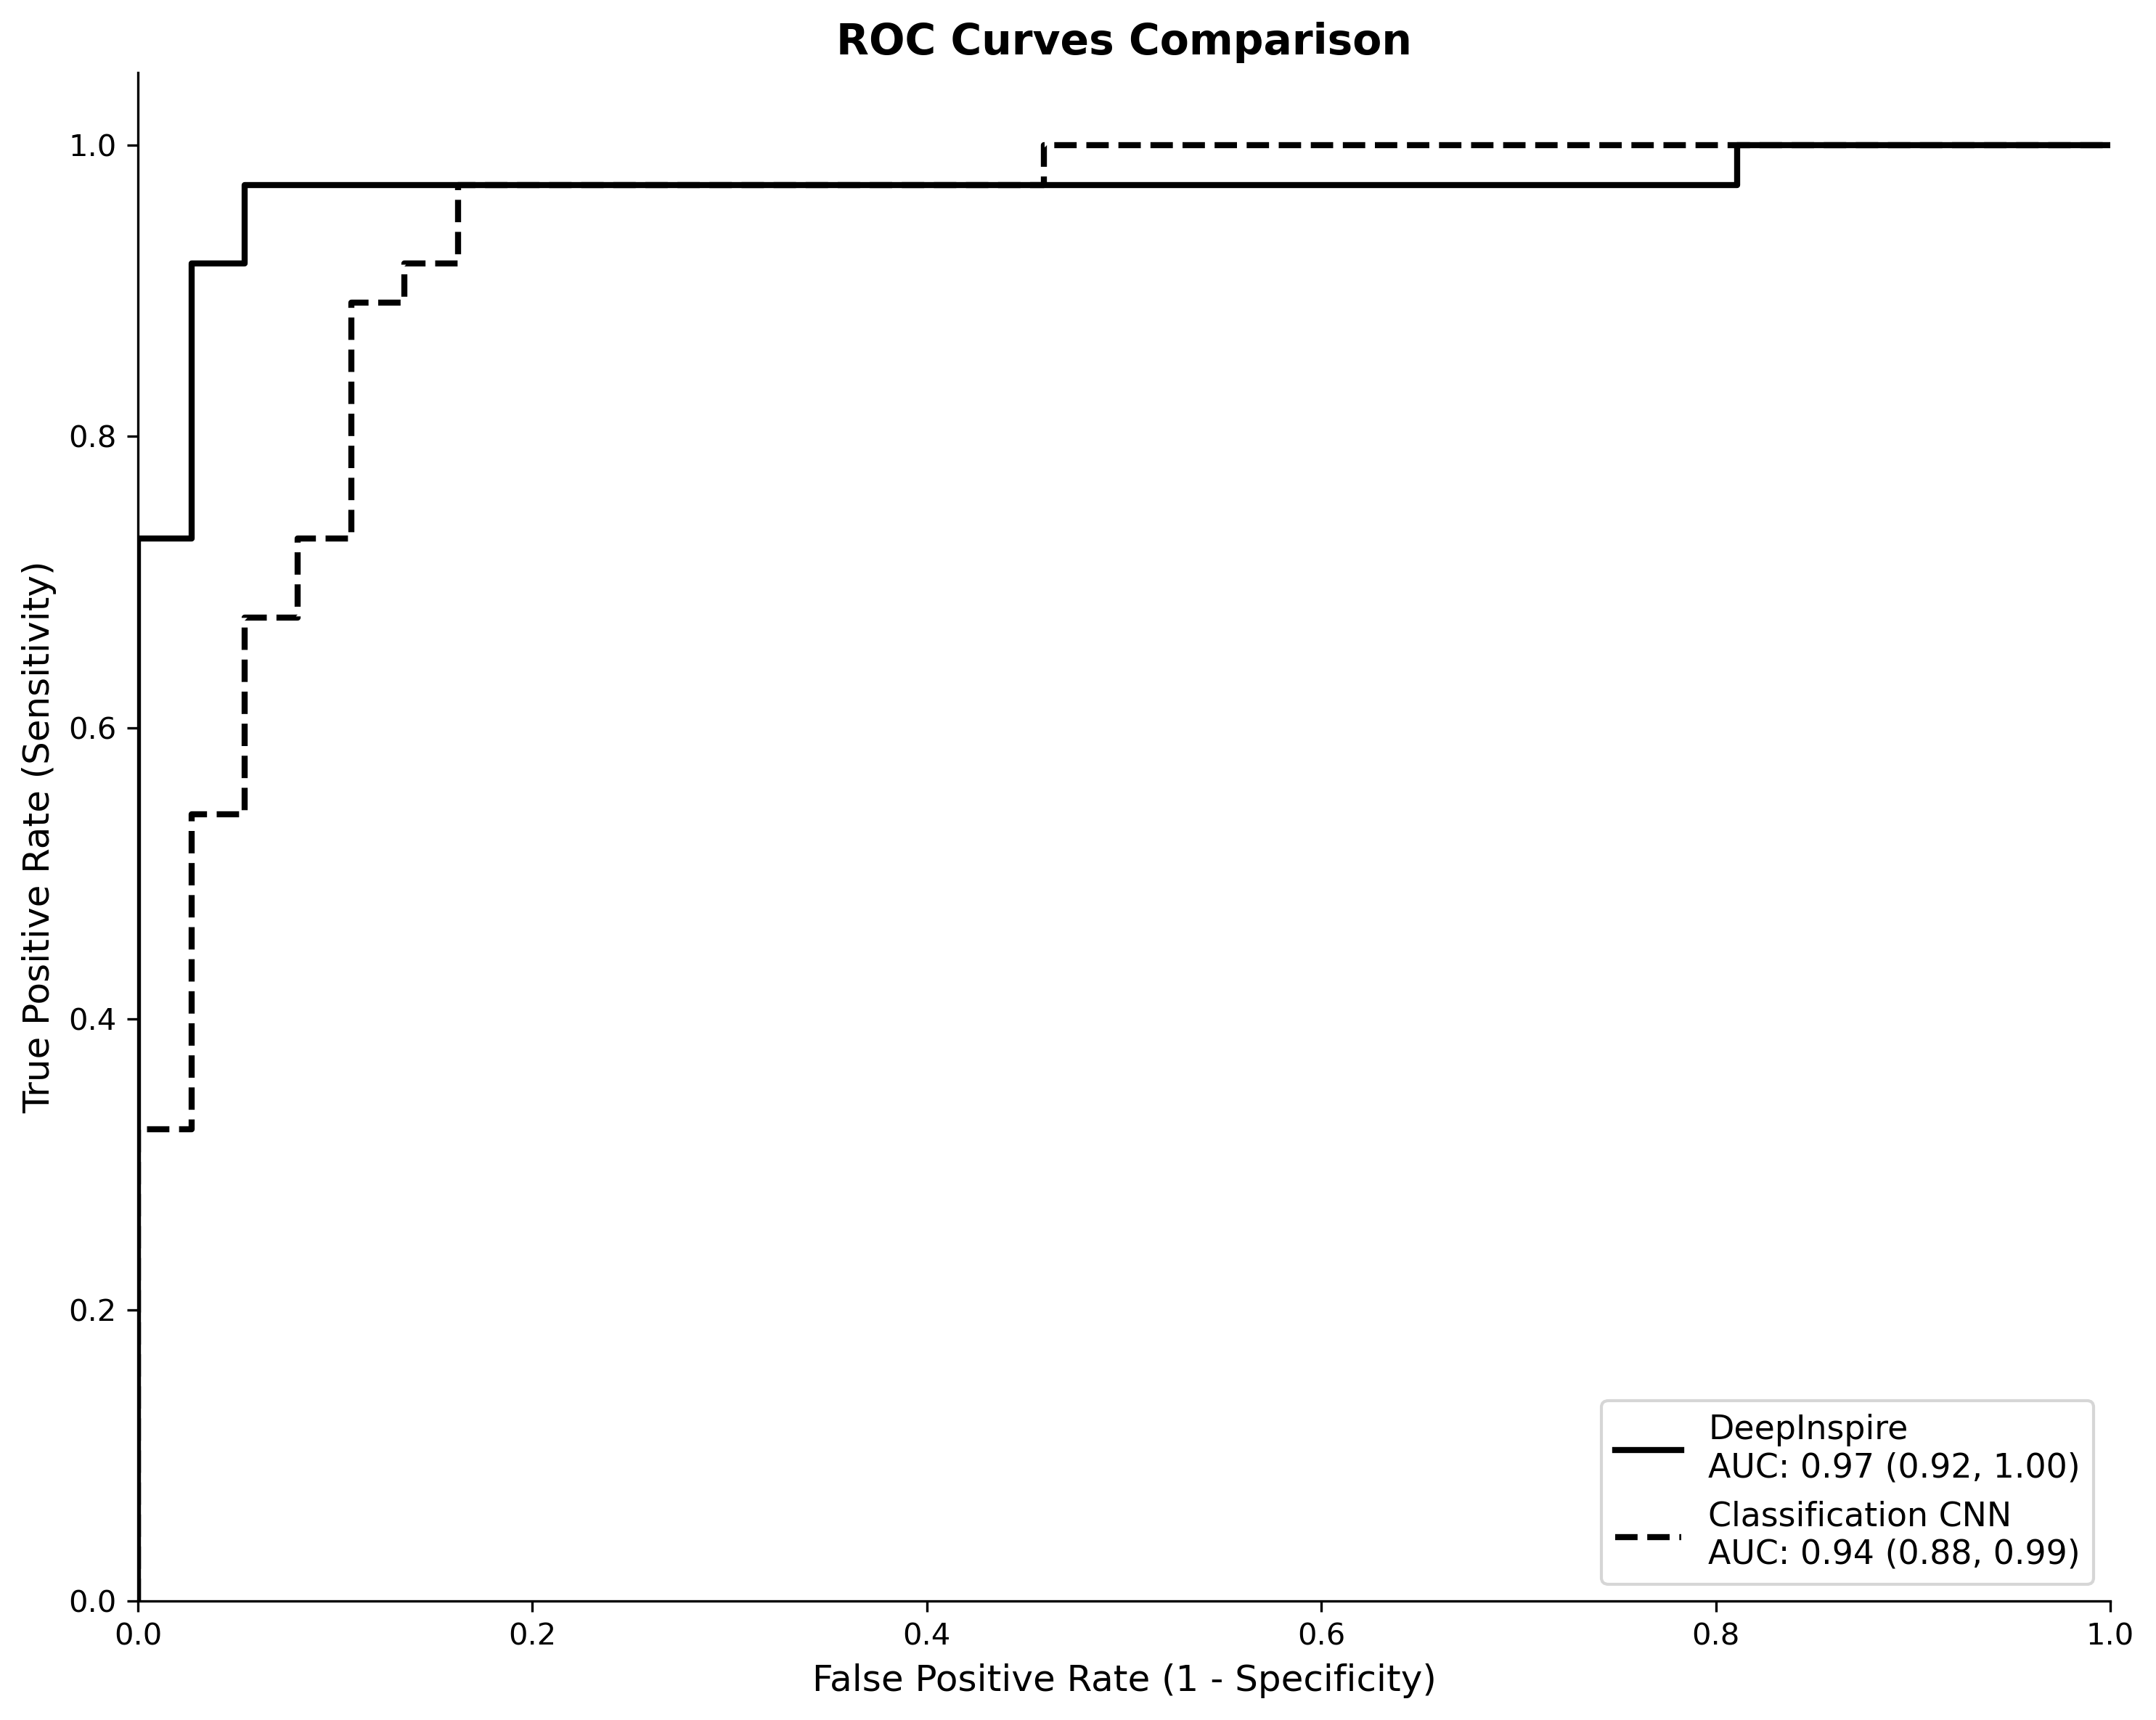


AUC Scores with 95% Confidence Intervals:
  - DeepInspire: 0.9701 [0.9162, 1.0000]
  - Classification CNN: 0.9401 [0.8791, 0.9854]
  - Difference: 0.0299

STATISTICAL COMPARISON

McNemar's Test Contingency Table:
  Both Correct: 63
  DeepInspire Correct Only: 6
  Classification Correct Only: 2
  Both Incorrect: 3

McNemar's Test Results:
  Discordant pairs: 8 (DeepInspire only: 6, Classification only: 2)
  P-value: 0.2891
  Conclusion: No statistically significant difference (p >= 0.05)

95% CONFIDENCE INTERVALS

95% Confidence Intervals (Wilson Score Method):

DeepInspire:
  Accuracy:    0.9324 [0.8514, 0.9708]
  Sensitivity: 0.8919 [0.7529, 0.9571]
  Specificity: 0.9730 [0.8618, 0.9952]
  AUC:         0.9701 [0.9162, 1.0000]  (Bootstrap)

Classification CNN:
  Accuracy:    0.8784 [0.7847, 0.9347]
  Sensitivity: 0.8919 [0.7529, 0.9571]
  Specificity: 0.8649 [0.7202, 0.9409]
  AUC:         0.9401 [0.8791, 0.9854]  (Bootstrap)

FALSE POSITIVES AND FALSE NEGATIVES ANALYSIS

DeepInspire 

In [27]:
# Run evaluation with DSC calculation
eval_results, roc_pack = evaluate_both_approaches(
    test_folder=test_image_folder,
    rib_model=rib_model,
    lung_model=lung_model,
    classification_model=model,
    device=device,
    rol_cutoff=optimal_results['optimal_rol_cutoff']
)

## 7. View Results

In [29]:
# Display results DataFrame
eval_results['results_df']

,image,true_label,deepinspire_pred,deepinspire_rol,classification_pred,classification_conf,deepinspire_correct,classification_correct
0,test_full_173.png,Adequate,Adequate,95.121951,Adequate,0.000068,True,True
1,test_full_198.png,Adequate,Adequate,94.860459,Adequate,0.000870,True,True
2,test_full_199.png,Adequate,Adequate,94.469487,Adequate,0.000741,True,True
3,test_full_172.png,Adequate,Adequate,95.103578,Adequate,0.001056,True,True
4,test_full_170.png,Adequate,Adequate,96.702526,Adequate,0.000025,True,True
...,...,...,...,...,...,...,...,...
69,test_notfull_065.png,Inadequate,Inadequate,80.946124,Inadequate,0.958149,True,True
70,test_notfull_059.png,Inadequate,Inadequate,73.992674,Inadequate,0.999884,True,True
71,test_notfull_058.png,Inadequate,Inadequate,67.920994,Inadequate,1.000000,True,True
72,test_notfull_064.png,Inadequate,Inadequate,58.092395,Inadequate,0.990269,True,True


In [30]:
# Display metrics comparison table
eval_results['metrics_comparison_df']

,Metric,DeepInspire,Classification
0,Accuracy,0.9324,0.8784
1,Sensitivity (Recall),0.8919,0.8919
2,Specificity,0.9730,0.8649
3,Precision,0.9706,0.8684
4,F1 Score,0.9296,0.8800


## 8. Export Results

In [31]:
# Export detailed results to CSV
eval_results['results_df'].to_csv('evaluation_results.csv', index=False)
print("✓ Results exported to evaluation_results.csv")

✓ Results exported to evaluation_results.csv


In [32]:
# Export metrics comparison to CSV
eval_results['metrics_comparison_df'].to_csv('metrics_comparison.csv', index=False)
print("✓ Metrics comparison exported to metrics_comparison.csv")

✓ Metrics comparison exported to metrics_comparison.csv


## 9. View False Positives and False Negatives

In [33]:
# View DeepInspire False Positives
print("DeepInspire False Positives:")
eval_results['false_positives']['deepinspire']

DeepInspire False Positives:


,image,true_label,deepinspire_pred,deepinspire_rol,classification_pred,classification_conf,deepinspire_correct,classification_correct
38,test_notfull_082.png,Inadequate,Adequate,84.217542,Adequate,0.002134,False,False
43,test_notfull_095.png,Inadequate,Adequate,86.888786,Inadequate,0.730119,False,True
64,test_notfull_072.png,Inadequate,Adequate,88.249400,Inadequate,0.962729,False,True
67,test_notfull_098.png,Inadequate,Adequate,96.957520,Adequate,0.117969,False,False


In [34]:
# View DeepInspire False Negatives
print("DeepInspire False Negatives:")
eval_results['false_negatives']['deepinspire']

DeepInspire False Negatives:


,image,true_label,deepinspire_pred,deepinspire_rol,classification_pred,classification_conf,deepinspire_correct,classification_correct
27,test_full_193.png,Adequate,Inadequate,76.379417,Inadequate,0.999357,False,False


In [35]:
# View Classification CNN False Positives
print("Classification CNN False Positives:")
eval_results['false_positives']['classification']

Classification CNN False Positives:


,image,true_label,deepinspire_pred,deepinspire_rol,classification_pred,classification_conf,deepinspire_correct,classification_correct
38,test_notfull_082.png,Inadequate,Adequate,84.217542,Adequate,0.002134,False,False
65,test_notfull_073.png,Inadequate,Inadequate,77.947761,Adequate,0.274355,True,False
66,test_notfull_067.png,Inadequate,Inadequate,72.127850,Adequate,0.442257,True,False
67,test_notfull_098.png,Inadequate,Adequate,96.957520,Adequate,0.117969,False,False


In [36]:
# View Classification CNN False Negatives
print("Classification CNN False Negatives:")
eval_results['false_negatives']['classification']

Classification CNN False Negatives:


,image,true_label,deepinspire_pred,deepinspire_rol,classification_pred,classification_conf,deepinspire_correct,classification_correct
8,test_full_159.png,Adequate,Adequate,85.479619,Inadequate,0.618166,True,False
24,test_full_192.png,Adequate,Adequate,91.687180,Inadequate,0.918549,True,False
25,test_full_186.png,Adequate,Adequate,95.291577,Inadequate,0.832066,True,False
27,test_full_193.png,Adequate,Inadequate,76.379417,Inadequate,0.999357,False,False
32,test_full_196.png,Adequate,Adequate,91.287813,Inadequate,0.990093,True,False


## 10. Human Performance Analysis

Compare model performance to technician interpretations:
- Calculate ICC (Intraclass Correlation Coefficient) for inter-rater reliability
- Compare models to majority vote (ground truth)
- Statistical tests to determine if models perform similarly to humans

In [37]:
# Load technician interpretations
tech_df = pd.read_csv(tech_data_path)

# Convert 1 to 1 (Inadequate/Not Full) and empty/NaN to 0 (Adequate/Full)
tech_columns = ['Tech1', 'Tech2', 'Tech3', 'Tech4', 'Tech5', 'Tech6', 'Tech 7', 'Tech 8', 'Tech 9']

# Create numeric version
tech_numeric = pd.DataFrame()
tech_numeric['image'] = tech_df['image'].astype(str)

for col in tech_columns:
    tech_numeric[col] = tech_df[col].apply(lambda x: 1 if str(x).strip() == '1.0' else 0)

print("Technician Interpretations Loaded:")
print(f"  Total images: {len(tech_numeric)}")
print(f"  Number of technicians: {len(tech_columns)}")
print(f"\nFirst few rows:")
print(tech_numeric.head(10))

Technician Interpretations Loaded:
  Total images: 74
  Number of technicians: 9

First few rows:
                  image  Tech1  Tech2  Tech3  Tech4  Tech5  Tech6  Tech 7  \
0  test_notfull_058.png      1      1      1      1      1      1       0   
1  test_notfull_059.png      1      1      1      1      0      1       0   
2  test_notfull_060.png      0      1      1      1      0      1       0   
3  test_notfull_061.png      1      1      1      1      1      1       0   
4  test_notfull_062.png      0      0      0      0      0      0       0   
5  test_notfull_063.png      1      1      1      1      1      1       1   
6  test_notfull_064.png      1      1      1      1      1      1       1   
7  test_notfull_065.png      1      1      1      1      1      1       1   
8  test_notfull_066.png      0      1      1      1      0      1       0   
9  test_notfull_067.png      1      1      1      1      1      1       1   

   Tech 8  Tech 9  
0       1       1  
1       0     

In [38]:
# Calculate ICC (Intraclass Correlation Coefficient)
# Using pingouin library for ICC calculation
try:
    import pingouin as pg
    icc_available = True
except ImportError:
    print("Installing pingouin for ICC calculation...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'pingouin'])
    import pingouin as pg
    icc_available = True

# Prepare data for ICC - need long format
icc_data = []
for idx, row in tech_numeric.iterrows():
    if pd.notna(row['image']):
        for tech_col in tech_columns:
            icc_data.append({
                'image': row['image'],
                'rater': tech_col,
                'rating': row[tech_col]
            })

icc_df = pd.DataFrame(icc_data)

# Calculate ICC(2,1) - two-way random effects, single rater
# This measures consistency among raters
icc_result = pg.intraclass_corr(data=icc_df, targets='image', raters='rater', ratings='rating')

print("=" * 80)
print("INTER-RATER RELIABILITY (ICC)")
print("=" * 80)
print("\nIntraclass Correlation Coefficient Results:")
print(icc_result.to_string(index=False))

# Extract ICC(2,1) which is appropriate for this scenario
icc_2_1 = icc_result[icc_result['Type'] == 'ICC2']['ICC'].values[0]
print(f"\n✓ ICC(2,1) = {icc_2_1:.4f}")

if icc_2_1 < 0.5:
    reliability = "Poor"
elif icc_2_1 < 0.75:
    reliability = "Moderate"
elif icc_2_1 < 0.9:
    reliability = "Good"
else:
    reliability = "Excellent"

print(f"  Interpretation: {reliability} inter-rater reliability")
print("\nGuideline:")
print("  < 0.50: Poor reliability")
print("  0.50-0.75: Moderate reliability")
print("  0.75-0.90: Good reliability")
print("  > 0.90: Excellent reliability")

INTER-RATER RELIABILITY (ICC)

Intraclass Correlation Coefficient Results:
 Type             Description      ICC         F  df1  df2         pval        CI95%
 ICC1  Single raters absolute 0.562095 12.552388   73  592 9.505460e-81 [0.47, 0.66]
 ICC2    Single random raters 0.565036 14.578782   73  584 2.310740e-91 [0.47, 0.66]
 ICC3     Single fixed raters 0.601396 14.578782   73  584 2.310740e-91 [0.52, 0.69]
ICC1k Average raters absolute 0.920334 12.552388   73  592 9.505460e-81 [0.89, 0.94]
ICC2k   Average random raters 0.921206 14.578782   73  584 2.310740e-91 [0.89, 0.95]
ICC3k    Average fixed raters 0.931407 14.578782   73  584 2.310740e-91 [0.91, 0.95]

✓ ICC(2,1) = 0.5650
  Interpretation: Moderate inter-rater reliability

Guideline:
  < 0.50: Poor reliability
  0.50-0.75: Moderate reliability
  0.75-0.90: Good reliability
  > 0.90: Excellent reliability


In [39]:
# Use ground truth (gt) column as reference
# Convert gt labels: '1' = 1 (Inadequate/Not Full), empty = 0 (Adequate/Full)
tech_numeric['gt_binary'] = tech_df['ground truth'].apply(lambda x: 1 if str(x).strip() == '1.0' else 0)
tech_numeric['agreement_count'] = tech_numeric[tech_columns].sum(axis=1)
tech_numeric['total_raters'] = tech_numeric[tech_columns].notna().sum(axis=1)
tech_numeric['proportion_inadequate'] = tech_numeric['agreement_count'] / tech_numeric['total_raters']

print("=" * 80)
print("GROUND TRUTH (GT) ANALYSIS")
print("=" * 80)
print(f"\nGround Truth labels:")
print(f"  Images classified as Inadequate (Not Full): {tech_numeric['gt_binary'].sum()}")
print(f"  Images classified as Adequate (Full): {(1 - tech_numeric['gt_binary']).sum()}")

print("\nTechnician Agreement with GT:")
for i in range(10):
    count = (tech_numeric['agreement_count'] == i).sum()
    if count > 0:
        print(f"  {i}/9 technicians voted Inadequate: {count} images")

print(f"\nMean proportion of technicians voting Inadequate: {tech_numeric['proportion_inadequate'].mean():.3f}")
print(f"Median proportion of technicians voting Inadequate: {tech_numeric['proportion_inadequate'].median():.3f}")

GROUND TRUTH (GT) ANALYSIS

Ground Truth labels:
  Images classified as Inadequate (Not Full): 37
  Images classified as Adequate (Full): 37

Technician Agreement with GT:
  0/9 technicians voted Inadequate: 34 images
  1/9 technicians voted Inadequate: 4 images
  2/9 technicians voted Inadequate: 3 images
  3/9 technicians voted Inadequate: 3 images
  4/9 technicians voted Inadequate: 5 images
  5/9 technicians voted Inadequate: 2 images
  6/9 technicians voted Inadequate: 7 images
  7/9 technicians voted Inadequate: 6 images
  8/9 technicians voted Inadequate: 5 images
  9/9 technicians voted Inadequate: 5 images

Mean proportion of technicians voting Inadequate: 0.327
Median proportion of technicians voting Inadequate: 0.111


In [40]:
eval_results['results_df']

,image,true_label,deepinspire_pred,deepinspire_rol,classification_pred,classification_conf,deepinspire_correct,classification_correct
0,test_full_173.png,Adequate,Adequate,95.121951,Adequate,0.000068,True,True
1,test_full_198.png,Adequate,Adequate,94.860459,Adequate,0.000870,True,True
2,test_full_199.png,Adequate,Adequate,94.469487,Adequate,0.000741,True,True
3,test_full_172.png,Adequate,Adequate,95.103578,Adequate,0.001056,True,True
4,test_full_170.png,Adequate,Adequate,96.702526,Adequate,0.000025,True,True
...,...,...,...,...,...,...,...,...
69,test_notfull_065.png,Inadequate,Inadequate,80.946124,Inadequate,0.958149,True,True
70,test_notfull_059.png,Inadequate,Inadequate,73.992674,Inadequate,0.999884,True,True
71,test_notfull_058.png,Inadequate,Inadequate,67.920994,Inadequate,1.000000,True,True
72,test_notfull_064.png,Inadequate,Inadequate,58.092395,Inadequate,0.990269,True,True


In [41]:
# Match technician data with evaluation results
# Extract image numbers from eval_results to match with tech data
eval_with_tech = eval_results['results_df'].copy()
eval_with_tech['image_num'] = eval_with_tech['image']

# Merge with technician data
eval_with_tech = eval_with_tech.merge(
    tech_numeric[['image', 'gt_binary', 'proportion_inadequate']], 
    left_on='image_num', 
    right_on='image',
    how='left',
    suffixes=('', '_tech')
)

# Convert to binary for comparison (1=Inadequate, 0=Adequate)
eval_with_tech['true_label_binary'] = (eval_with_tech['true_label'] == 'Inadequate').astype(int)
eval_with_tech['deepinspire_pred_binary'] = (eval_with_tech['deepinspire_pred'] == 'Inadequate').astype(int)
eval_with_tech['classification_pred_binary'] = (eval_with_tech['classification_pred'] == 'Inadequate').astype(int)

# Filter to only images that have technician data
eval_with_tech_valid = eval_with_tech[eval_with_tech['gt_binary'].notna()].copy()

print("=" * 80)
print("MODEL vs HUMAN COMPARISON")
print("=" * 80)
print(f"\nImages with technician data: {len(eval_with_tech_valid)}")
print(f"Images without technician data: {len(eval_with_tech) - len(eval_with_tech_valid)}")

if len(eval_with_tech_valid) > 0:
    print("\nUsing ground truth (GT) as reference for comparison...")

MODEL vs HUMAN COMPARISON

Images with technician data: 74
Images without technician data: 0

Using ground truth (GT) as reference for comparison...


In [42]:
# Calculate individual technician performance against ground truth
print("=" * 80)
print("INDIVIDUAL TECHNICIAN PERFORMANCE")
print("=" * 80)

tech_performance = []
for tech_col in tech_columns:
    # Get technician ratings for images with ground truth
    tech_ratings = []
    gt_ratings = []
    
    for idx, row in tech_numeric.iterrows():
        if pd.notna(row['image']) and pd.notna(row[tech_col]) and pd.notna(row['gt_binary']):
            tech_ratings.append(row[tech_col])
            gt_ratings.append(row['gt_binary'])
    
    if len(tech_ratings) > 0:
        tech_ratings = np.array(tech_ratings)
        gt_ratings = np.array(gt_ratings)
        
        # Calculate metrics
        accuracy = accuracy_score(gt_ratings, tech_ratings)
        cm = confusion_matrix(gt_ratings, tech_ratings)
        tn, fp, fn, tp = cm.ravel()
        
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0
        
        tech_performance.append({
            'Technician': tech_col,
            'Accuracy': accuracy,
            'Sensitivity': sensitivity,
            'Specificity': specificity,
            'Precision': precision,
            'F1': f1,
            'N_images': len(tech_ratings)
        })

tech_perf_df = pd.DataFrame(tech_performance)
print("\nTechnician Performance (vs Ground Truth):")
print(tech_perf_df.to_string(index=False))


print(f"  Precision:   {tech_perf_df['Precision'].mean():.4f} ± {tech_perf_df['Precision'].std():.4f}")
print(f"\nAverage Human Performance:")
print(f"  Specificity: {tech_perf_df['Specificity'].mean():.4f} ± {tech_perf_df['Specificity'].std():.4f}")

print(f"  F1 Score:    {tech_perf_df['F1'].mean():.4f} ± {tech_perf_df['F1'].std():.4f}")
print(f"  Accuracy:    {tech_perf_df['Accuracy'].mean():.4f} ± {tech_perf_df['Accuracy'].std():.4f}")
print(f"  Sensitivity: {tech_perf_df['Sensitivity'].mean():.4f} ± {tech_perf_df['Sensitivity'].std():.4f}")

INDIVIDUAL TECHNICIAN PERFORMANCE

Technician Performance (vs Ground Truth):
Technician  Accuracy  Sensitivity  Specificity  Precision       F1  N_images
     Tech1  0.783784     0.594595     0.972973   0.956522 0.733333        74
     Tech2  0.891892     0.918919     0.864865   0.871795 0.894737        74
     Tech3  0.891892     0.783784     1.000000   1.000000 0.878788        74
     Tech4  0.851351     0.702703     1.000000   1.000000 0.825397        74
     Tech5  0.716216     0.459459     0.972973   0.944444 0.618182        74
     Tech6  0.891892     0.837838     0.945946   0.939394 0.885714        74
    Tech 7  0.662162     0.351351     0.972973   0.928571 0.509804        74
    Tech 8  0.648649     0.297297     1.000000   1.000000 0.458333        74
    Tech 9  0.810811     0.648649     0.972973   0.960000 0.774194        74
  Precision:   0.9556 ± 0.0419

Average Human Performance:
  Specificity: 0.9670 ± 0.0423
  F1 Score:    0.7309 ± 0.1656
  Accuracy:    0.7943 ± 0.0981
 

MODEL PERFORMANCE vs GROUND TRUTH (HUMAN REFERENCE)

Performance vs Ground Truth (n=74 images):
     Metric Human Avg DeepInspire Classification
   Accuracy    0.7943      0.9324         0.8784
Sensitivity    0.6216      0.8919         0.8919
Specificity    0.9670      0.9730         0.8649
  Precision    0.9556      0.9706         0.8684
   F1 Score    0.7309      0.9296         0.8800

RADAR CHART COMPARISON


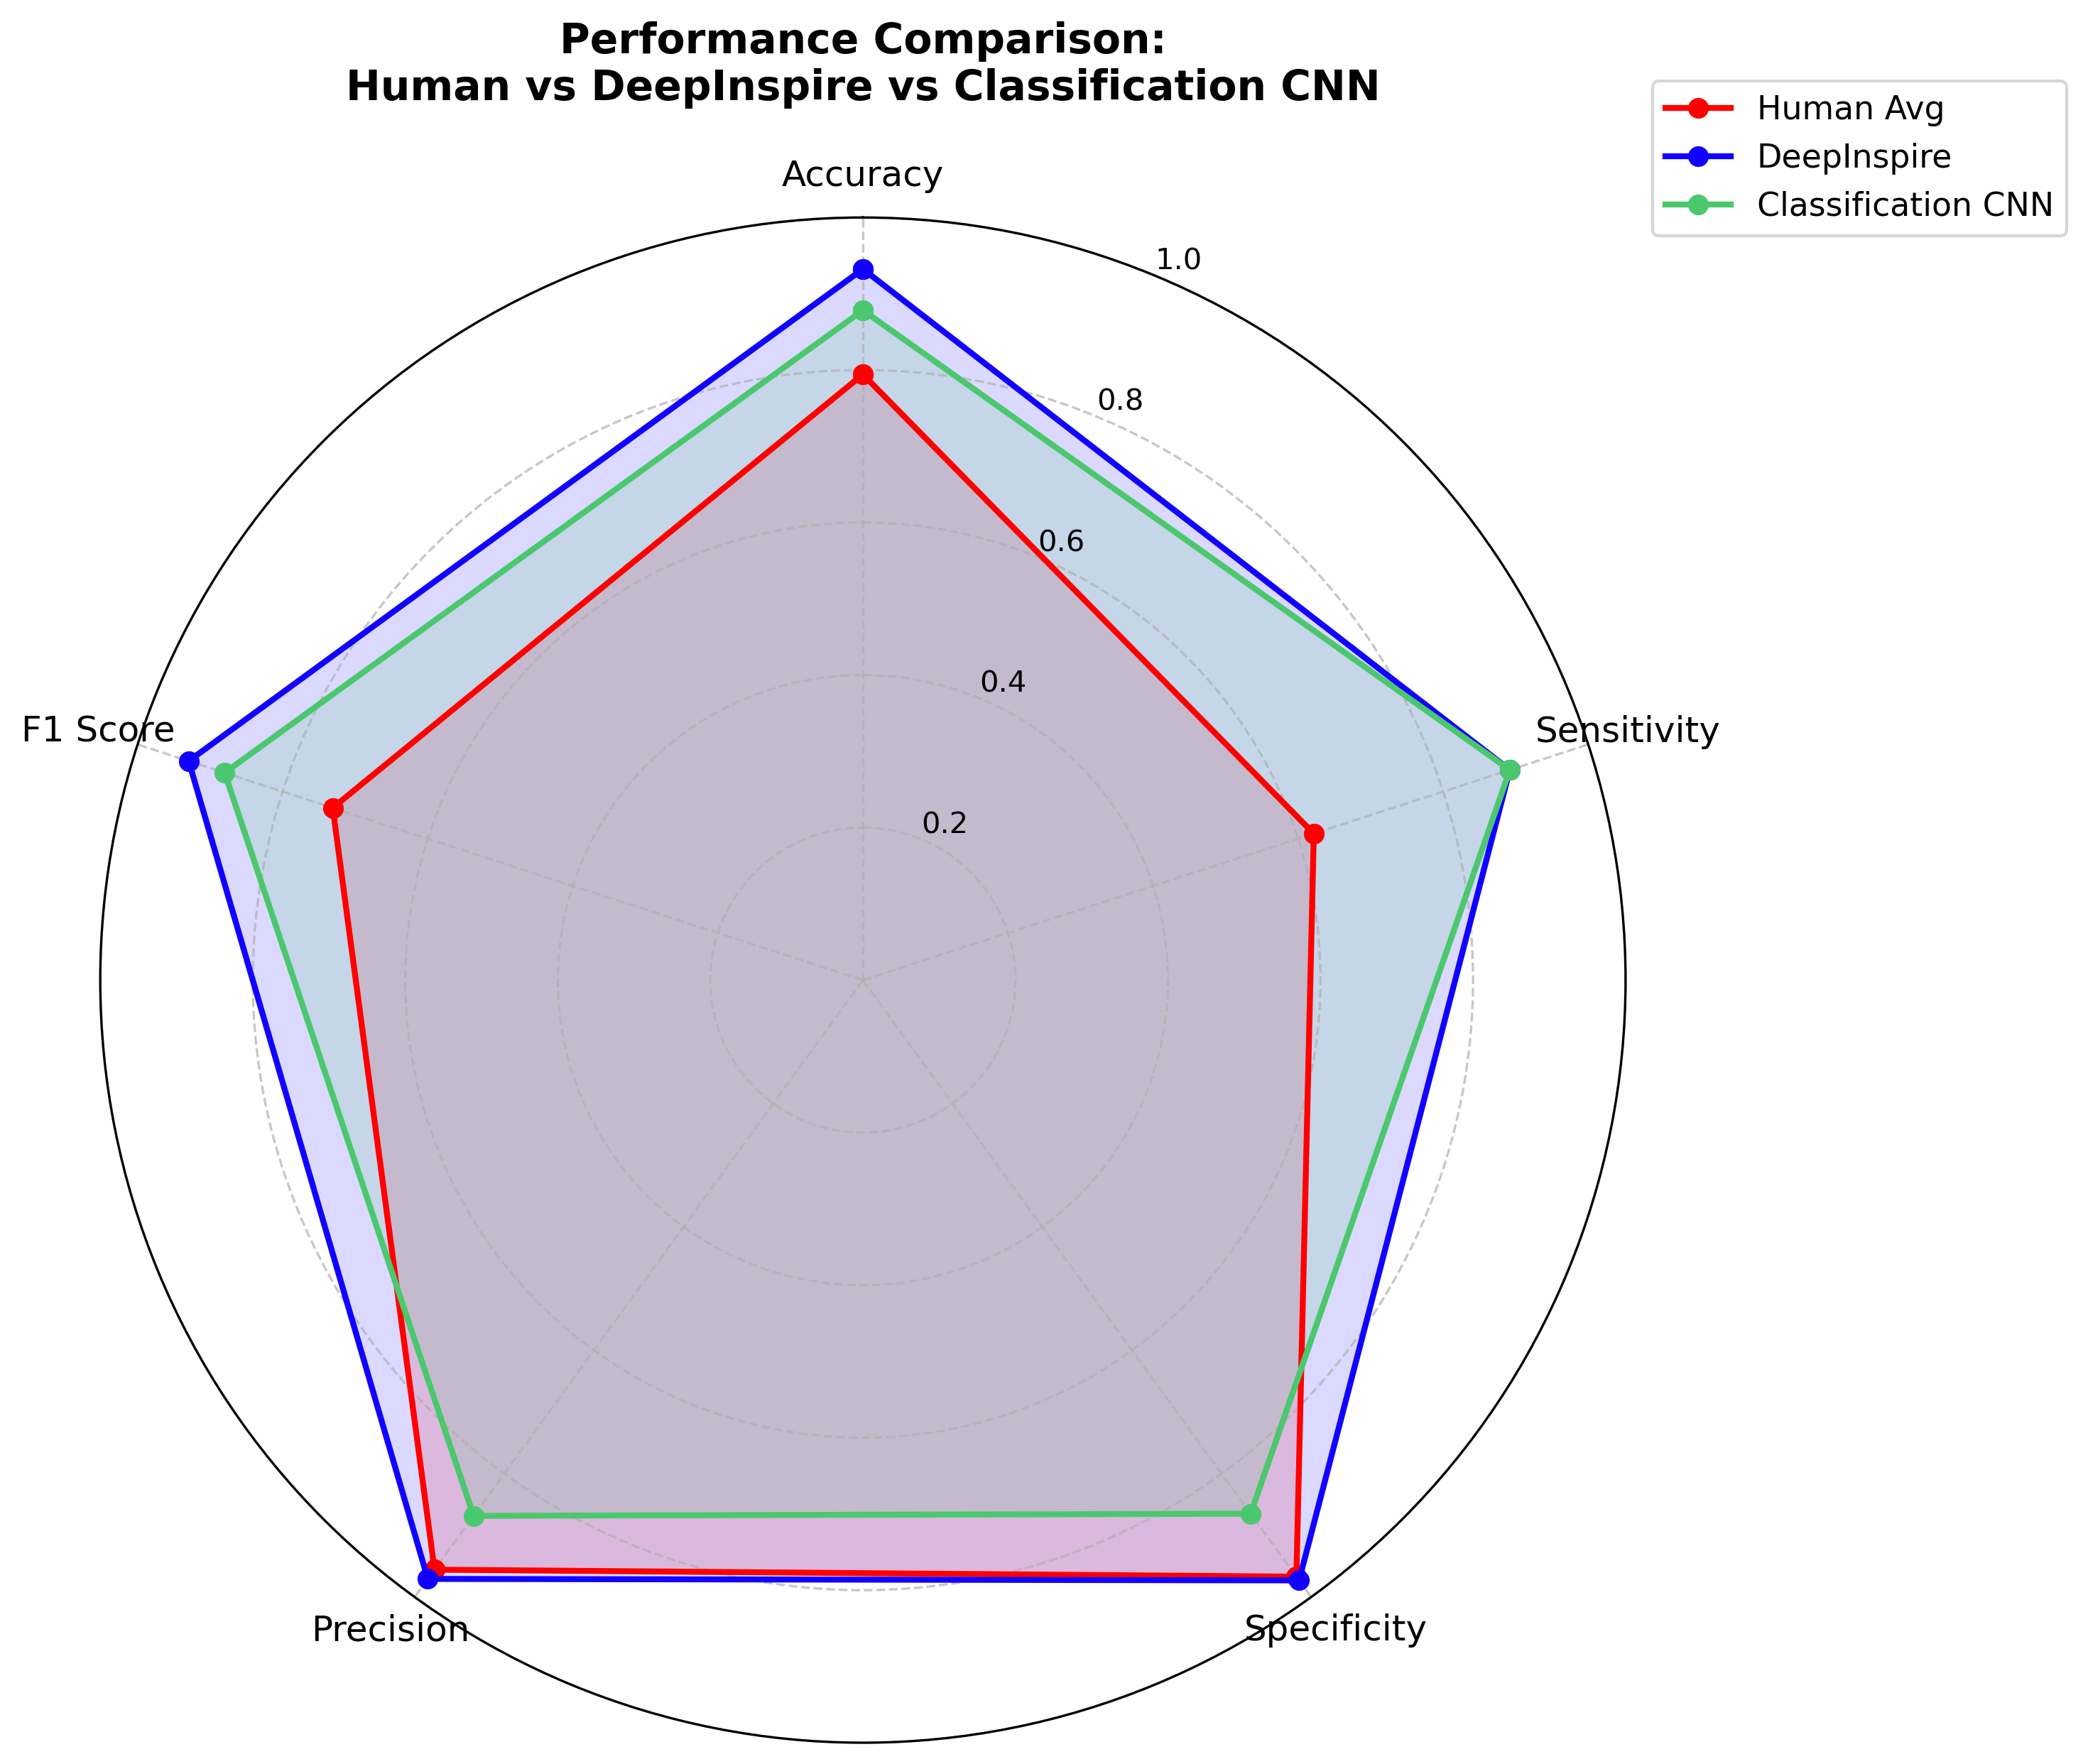


✓ Radar chart shows comparative performance across all metrics


/opt/homebrew/Caskroom/miniforge/base/envs/ml/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.5.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


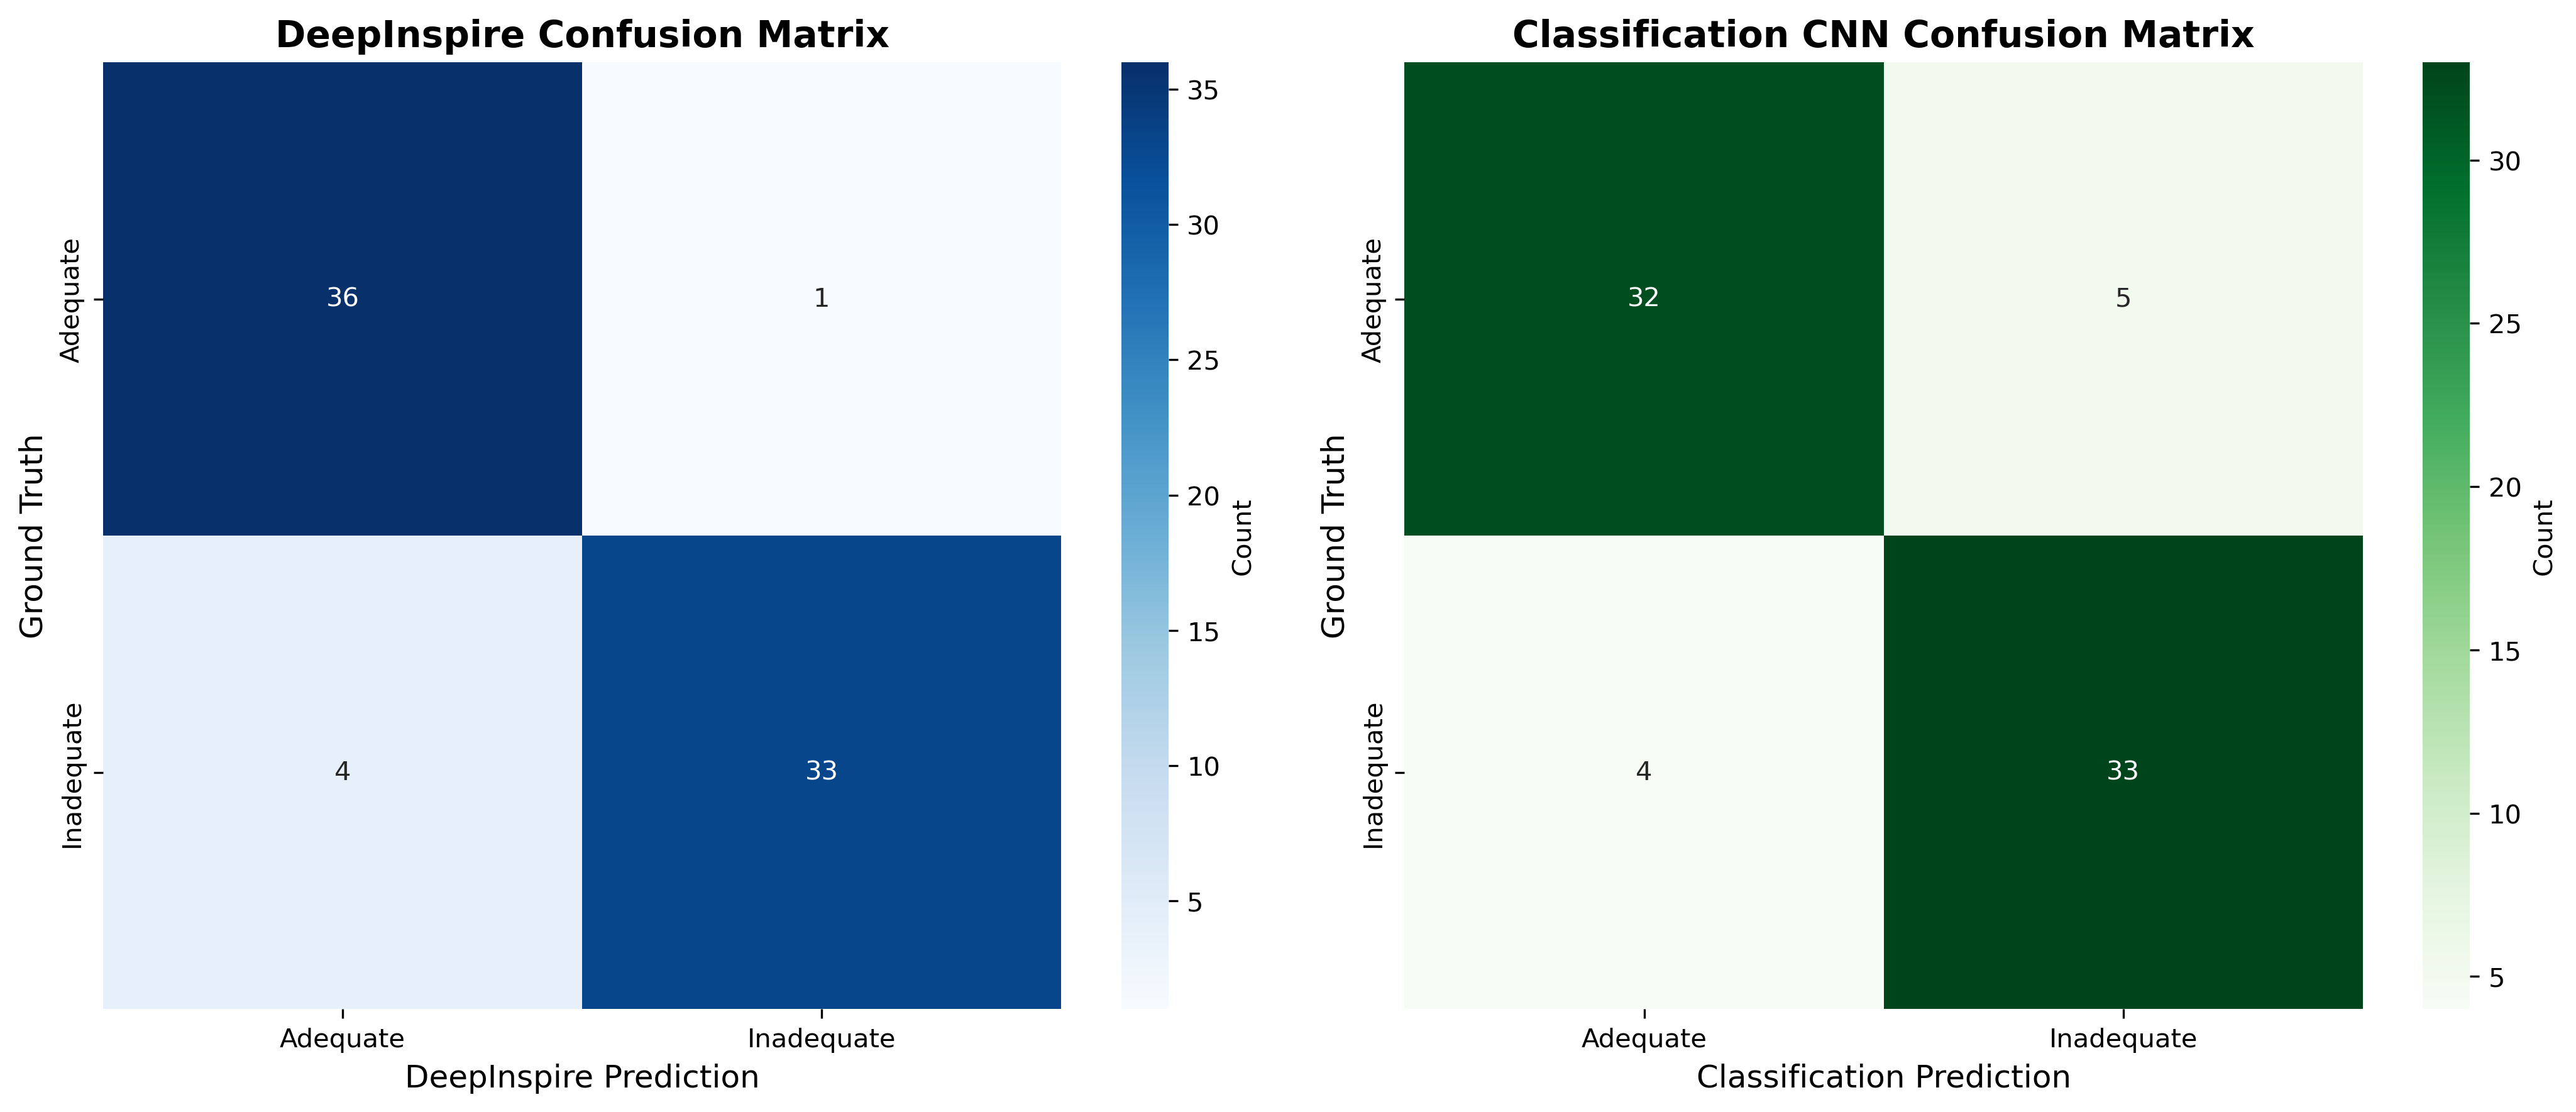

In [43]:
# Compare models to ground truth (human reference)
print("=" * 80)
print("MODEL PERFORMANCE vs GROUND TRUTH (HUMAN REFERENCE)")
print("=" * 80)

if len(eval_with_tech_valid) > 0:
    # Get predictions and ground truth
    y_gt = eval_with_tech_valid['gt_binary'].values
    y_deepinspire = eval_with_tech_valid['deepinspire_pred_binary'].values
    y_classification = eval_with_tech_valid['classification_pred_binary'].values
    
    # Calculate metrics for models vs ground truth
    cm_di_gt = confusion_matrix(y_gt, y_deepinspire)
    cm_clf_gt = confusion_matrix(y_gt, y_classification)
    
    def calc_metrics_vs_human(y_true, y_pred, cm):
        tn, fp, fn, tp = cm.ravel()
        acc = accuracy_score(y_true, y_pred)
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        prec = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        return {'Accuracy': acc, 'Sensitivity': sens, 'Specificity': spec, 
                'Precision': prec, 'F1': f1, 'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn}
    
    metrics_di_gt = calc_metrics_vs_human(y_gt, y_deepinspire, cm_di_gt)
    metrics_clf_gt = calc_metrics_vs_human(y_gt, y_classification, cm_clf_gt)
    
    # Create comparison table
    comparison_df = pd.DataFrame({
        'Metric': ['Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F1 Score'],
        'Human Avg': [
            f"{tech_perf_df['Accuracy'].mean():.4f}",
            f"{tech_perf_df['Sensitivity'].mean():.4f}",
            f"{tech_perf_df['Specificity'].mean():.4f}",
            f"{tech_perf_df['Precision'].mean():.4f}",
            f"{tech_perf_df['F1'].mean():.4f}"
        ],
        'DeepInspire': [
            f"{metrics_di_gt['Accuracy']:.4f}",
            f"{metrics_di_gt['Sensitivity']:.4f}",
            f"{metrics_di_gt['Specificity']:.4f}",
            f"{metrics_di_gt['Precision']:.4f}",
            f"{metrics_di_gt['F1']:.4f}"
        ],
        'Classification': [
            f"{metrics_clf_gt['Accuracy']:.4f}",
            f"{metrics_clf_gt['Sensitivity']:.4f}",
            f"{metrics_clf_gt['Specificity']:.4f}",
            f"{metrics_clf_gt['Precision']:.4f}",
            f"{metrics_clf_gt['F1']:.4f}"
        ]
    })
    
    print(f"\nPerformance vs Ground Truth (n={len(eval_with_tech_valid)} images):")
    print(comparison_df.to_string(index=False))
    
    # Radar chart comparison
    print("\n" + "=" * 80)
    print("RADAR CHART COMPARISON")
    print("=" * 80)
    
    # Prepare data for radar chart
    metrics_names = ['Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F1 Score']
    human_values = [
        tech_perf_df['Accuracy'].mean(),
        tech_perf_df['Sensitivity'].mean(),
        tech_perf_df['Specificity'].mean(),
        tech_perf_df['Precision'].mean(),
        tech_perf_df['F1'].mean()
    ]
    deepinspire_values = [
        metrics_di_gt['Accuracy'],
        metrics_di_gt['Sensitivity'],
        metrics_di_gt['Specificity'],
        metrics_di_gt['Precision'],
        metrics_di_gt['F1']
    ]
    classification_values = [
        metrics_clf_gt['Accuracy'],
        metrics_clf_gt['Sensitivity'],
        metrics_clf_gt['Specificity'],
        metrics_clf_gt['Precision'],
        metrics_clf_gt['F1']
    ]
    
    # Number of variables
    num_vars = len(metrics_names)
    
    # Compute angle for each axis
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    
    # Complete the circle
    human_values += human_values[:1]
    deepinspire_values += deepinspire_values[:1]
    classification_values += classification_values[:1]
    angles += angles[:1]
    
    pack_radar = (angles, human_values, deepinspire_values, classification_values)
    # Create radar chart
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'), dpi=300)
    
    # Plot data
    ax.plot(angles, human_values, 'o-', linewidth=2, label='Human Avg', color="#FF0000")
    ax.fill(angles, human_values, alpha=0.15, color="#FF0000")
    
    ax.plot(angles, deepinspire_values, 'o-', linewidth=2, label='DeepInspire', color="#1100FF")
    ax.fill(angles, deepinspire_values, alpha=0.15, color="#1100FF")
    
    ax.plot(angles, classification_values, 'o-', linewidth=2, label='Classification CNN', color="#4BC86D")
    ax.fill(angles, classification_values, alpha=0.15, color="#4BC86D")
    
    # Fix axis to go in the right order and start at 12 o'clock
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    
    # Draw axis lines for each angle and label
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics_names, size=12)
    
    # Set y-axis limits and labels
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], size=10)
    
    # Add legend and title
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
    ax.set_title('Performance Comparison:\nHuman vs DeepInspire vs Classification CNN', 
                 size=14, fontweight='bold', pad=20)
    
    # Add grid
    ax.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Radar chart shows comparative performance across all metrics")
    
    # Confusion matrices
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=300)
    
    sns.heatmap(cm_di_gt, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Adequate', 'Inadequate'],
                yticklabels=['Adequate', 'Inadequate'],
                ax=axes[0], cbar_kws={'label': 'Count'})
    axes[0].set_title('DeepInspire Confusion Matrix', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Ground Truth', fontsize=12)
    axes[0].set_xlabel('DeepInspire Prediction', fontsize=12)
    
    sns.heatmap(cm_clf_gt, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Adequate', 'Inadequate'],
                yticklabels=['Adequate', 'Inadequate'],
                ax=axes[1], cbar_kws={'label': 'Count'})
    axes[1].set_title('Classification CNN Confusion Matrix', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Ground Truth', fontsize=12)
    axes[1].set_xlabel('Classification Prediction', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("\nNo matching images found between evaluation and technician data.")

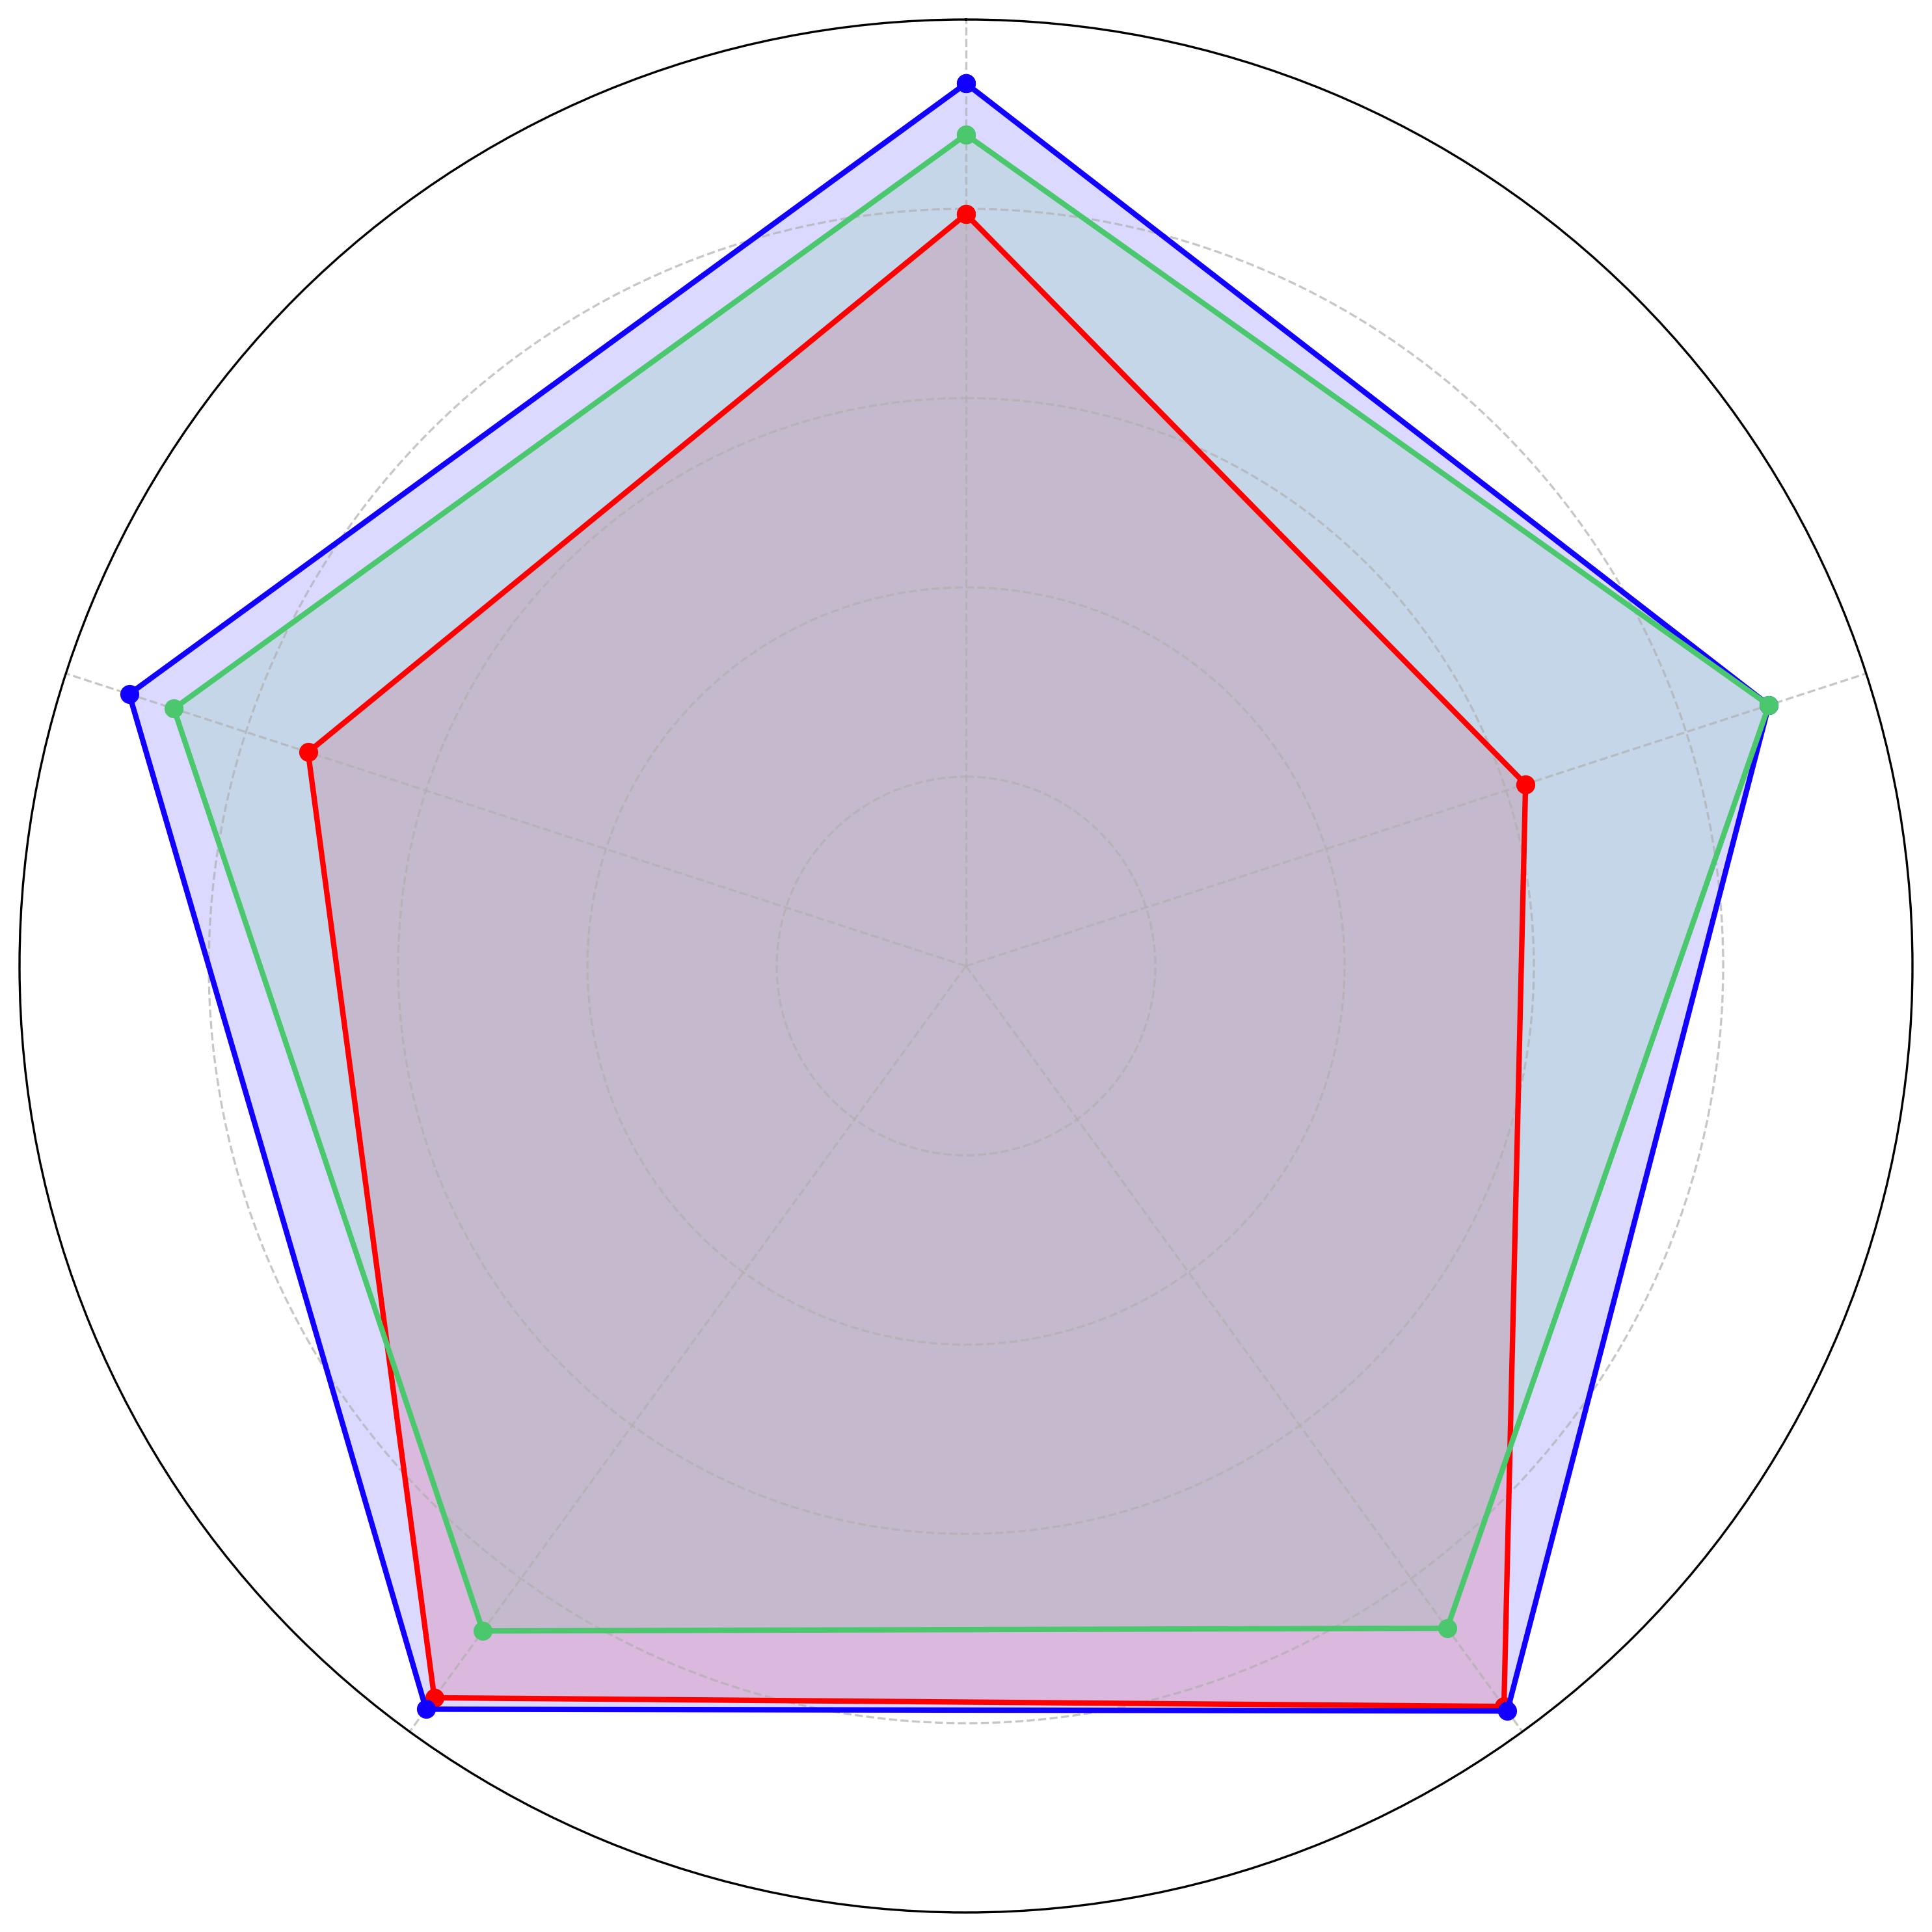

In [65]:
# Create radar chart
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'), dpi=300)

# Plot data
ax.plot(angles, human_values, 'o-', linewidth=2, label='Human Avg', color="#FF0000")
ax.fill(angles, human_values, alpha=0.15, color="#FF0000")

ax.plot(angles, deepinspire_values, 'o-', linewidth=2, label='DeepInspire', color="#1100FF")
ax.fill(angles, deepinspire_values, alpha=0.15, color="#1100FF")

ax.plot(angles, classification_values, 'o-', linewidth=2, label='Classification CNN', color="#4BC86D")
ax.fill(angles, classification_values, alpha=0.15, color="#4BC86D")

# Fix axis to go in the right order and start at 12 o'clock
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Draw axis lines for each angle and label
ax.set_xticks(angles[:-1])
ax.set_xticklabels('', size=12)

# Set y-axis limits and labels
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['', '', '', '', ''], size=10)

# Add legend and title
# ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
# ax.set_title('Performance Comparison:\nHuman vs DeepInspire vs Classification CNN', 
#              size=14, fontweight='bold', pad=20)

# Add grid
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [44]:
# Statistical tests: Are models performing similar to humans?
print("=" * 80)
print("STATISTICAL COMPARISON: MODELS vs HUMANS")
print("=" * 80)

if len(eval_with_tech_valid) > 0:
    # 1. Compare model accuracy to average human accuracy using one-sample t-test
    from scipy.stats import ttest_1samp
    
    human_mean_acc = tech_perf_df['Accuracy'].mean()
    human_std_acc = tech_perf_df['Accuracy'].std()
    
    print("\n1. Model Accuracy vs Average Human Performance")
    print(f"   Average Human Accuracy: {human_mean_acc:.4f} ± {human_std_acc:.4f}")
    print(f"   DeepInspire Accuracy: {metrics_di_gt['Accuracy']:.4f}")
    print(f"   Classification Accuracy: {metrics_clf_gt['Accuracy']:.4f}")
    
    # Calculate z-score to see if model falls within human range
    z_di = (metrics_di_gt['Accuracy'] - human_mean_acc) / human_std_acc if human_std_acc > 0 else 0
    z_clf = (metrics_clf_gt['Accuracy'] - human_mean_acc) / human_std_acc if human_std_acc > 0 else 0
    
    print(f"\n   DeepInspire z-score: {z_di:.2f}")
    print(f"   Classification z-score: {z_clf:.2f}")
    print(f"   (|z| < 1.96 suggests model performs within 95% CI of human performance)")
    
    if abs(z_di) < 1.96:
        print(f"   ✓ DeepInspire performs NOT significantly different from humans (|z| < 1.96)")
    else:
        print(f"   ✗ DeepInspire performs significantly different from humans (|z| >= 1.96)")
    
    if abs(z_clf) < 1.96:
        print(f"   ✓ Classification performs NOT significantly different from humans (|z| < 1.96)")
    else:
        print(f"   ✗ Classification performs significantly different from humans (|z| >= 1.96)")
    
    # 2. Cohen's Kappa - agreement beyond chance
    from sklearn.metrics import cohen_kappa_score
    
    print("\n2. Cohen's Kappa (Agreement with Ground Truth)")
    kappa_di = cohen_kappa_score(y_gt, y_deepinspire)
    kappa_clf = cohen_kappa_score(y_gt, y_classification)
    
    # Calculate average human kappa
    human_kappas = []
    for tech_col in tech_columns:
        tech_ratings = []
        gt_ratings = []
        for idx, row in tech_numeric.iterrows():
            if pd.notna(row['image']) and pd.notna(row[tech_col]) and pd.notna(row['gt_binary']):
                tech_ratings.append(row[tech_col])
                gt_ratings.append(row['gt_binary'])
        if len(tech_ratings) > 0:
            kappa = cohen_kappa_score(gt_ratings, tech_ratings)
            human_kappas.append(kappa)
    
    human_mean_kappa = np.mean(human_kappas)
    human_std_kappa = np.std(human_kappas)
    
    print(f"   Average Human Kappa: {human_mean_kappa:.4f} ± {human_std_kappa:.4f}")
    print(f"   DeepInspire Kappa: {kappa_di:.4f}")
    print(f"   Classification Kappa: {kappa_clf:.4f}")
    
    print(f"\n   Kappa Interpretation:")
    print(f"   < 0.20: Slight agreement")
    print(f"   0.21-0.40: Fair agreement")
    print(f"   0.41-0.60: Moderate agreement")
    print(f"   0.61-0.80: Substantial agreement")
    print(f"   > 0.80: Almost perfect agreement")
    
    # 3. McNemar's test comparing models to best human
    print("\n3. McNemar's Test: Models vs Best Human Technician")
    best_human_idx = tech_perf_df['Accuracy'].idxmax()
    best_human_name = tech_perf_df.loc[best_human_idx, 'Technician']
    best_human_acc = tech_perf_df.loc[best_human_idx, 'Accuracy']
    
    # Get best human predictions
    best_human_ratings = []
    best_human_images = []
    for idx, row in tech_numeric.iterrows():
        if pd.notna(row['image']) and pd.notna(row[best_human_name]):
            best_human_ratings.append(row[best_human_name])
            best_human_images.append(row['image'])
    
    # Match with model predictions
    eval_matched = eval_with_tech_valid[eval_with_tech_valid['image_tech'].isin(best_human_images)].copy()
    
    if len(eval_matched) > 0:
        # Get corresponding predictions
        y_best_human = []
        y_di_matched = []
        y_clf_matched = []
        
        for idx, row in eval_matched.iterrows():
            img_idx = tech_numeric[tech_numeric['image'] == row['image_tech']].index[0]
            y_best_human.append(tech_numeric.loc[img_idx, best_human_name])
            y_di_matched.append(row['deepinspire_pred_binary'])
            y_clf_matched.append(row['classification_pred_binary'])
        
        y_best_human = np.array(y_best_human)
        y_di_matched = np.array(y_di_matched)
        y_clf_matched = np.array(y_clf_matched)
        
        # Get corresponding ground truth
        y_gt_matched = []
        for idx, row in eval_matched.iterrows():
            img_idx = tech_numeric[tech_numeric['image'] == row['image_tech']].index[0]
            y_gt_matched.append(tech_numeric.loc[img_idx, 'gt_binary'])
        y_gt_matched = np.array(y_gt_matched)
        
        # McNemar test: DeepInspire vs Best Human
        both_correct_di = sum((y_di_matched == y_gt_matched) & 
                              (y_best_human == y_gt_matched))
        di_only = sum((y_di_matched == y_gt_matched) & 
                      (y_best_human != y_gt_matched))
        human_only = sum((y_di_matched != y_gt_matched) & 
                         (y_best_human == y_gt_matched))
        
        n_discordant = di_only + human_only
        if n_discordant > 0:
            p_value_di = 2 * min(stats.binom.cdf(min(di_only, human_only), n_discordant, 0.5),
                                 1 - stats.binom.cdf(min(di_only, human_only) - 1, n_discordant, 0.5))
        else:
            p_value_di = 1.0
        
        # McNemar test: Classification vs Best Human
        both_correct_clf = sum((y_clf_matched == y_gt_matched) & 
                               (y_best_human == y_gt_matched))
        clf_only = sum((y_clf_matched == y_gt_matched) & 
                       (y_best_human != y_gt_matched))
        
        n_discordant_clf = clf_only + human_only
        if n_discordant_clf > 0:
            p_value_clf = 2 * min(stats.binom.cdf(min(clf_only, human_only), n_discordant_clf, 0.5),
                                  1 - stats.binom.cdf(min(clf_only, human_only) - 1, n_discordant_clf, 0.5))
        else:
            p_value_clf = 1.0
        
        print(f"   Best Human: {best_human_name} (Accuracy: {best_human_acc:.4f})")
        print(f"\n   DeepInspire vs {best_human_name}:")
        print(f"     Discordant pairs: {n_discordant}")
        print(f"     DeepInspire correct only: {di_only}")
        print(f"     {best_human_name} correct only: {human_only}")
        print(f"     P-value: {p_value_di:.4f}")
        if p_value_di >= 0.05:
            print(f"     ✓ NO significant difference (p >= 0.05) - Model performs like best human!")
        else:
            print(f"     ✗ Significant difference (p < 0.05)")
        
        print(f"\n   Classification vs {best_human_name}:")
        print(f"     Discordant pairs: {n_discordant_clf}")
        print(f"     Classification correct only: {clf_only}")
        print(f"     {best_human_name} correct only: {human_only}")
        print(f"     P-value: {p_value_clf:.4f}")
        if p_value_clf >= 0.05:
            print(f"     ✓ NO significant difference (p >= 0.05) - Model performs like best human!")
        else:
            print(f"     ✗ Significant difference (p < 0.05)")
    
    # 4. Summary
    print("\n" + "=" * 80)
    print("SUMMARY: Do Models Perform Like Humans?")
    print("=" * 80)
    
    print(f"\nDeepInspire:")
    print(f"  - Accuracy: {metrics_di_gt['Accuracy']:.4f} (Human avg: {human_mean_acc:.4f})")
    print(f"  - Agreement (Kappa): {kappa_di:.4f} (Human avg: {human_mean_kappa:.4f})")
    print(f"  - Z-score: {z_di:.2f} ({'within' if abs(z_di) < 1.96 else 'outside'} human 95% CI)")
    
    print(f"\nClassification CNN:")
    print(f"  - Accuracy: {metrics_clf_gt['Accuracy']:.4f} (Human avg: {human_mean_acc:.4f})")
    print(f"  - Agreement (Kappa): {kappa_clf:.4f} (Human avg: {human_mean_kappa:.4f})")
    print(f"  - Z-score: {z_clf:.2f} ({'within' if abs(z_clf) < 1.96 else 'outside'} human 95% CI)")
    
    print(f"\n{'✓' if abs(z_di) < 1.96 and abs(z_clf) < 1.96 else '⚠'} Conclusion:")
    if abs(z_di) < 1.96 and abs(z_clf) < 1.96:
        print("  Both models perform NOT significantly different from human technicians!")
        print("  Models achieve human-level performance on this task.")
    elif abs(z_di) < 1.96:
        print("  DeepInspire performs NOT significantly different from humans.")
        print("  Classification CNN shows significant difference from human performance.")
    elif abs(z_clf) < 1.96:
        print("  Classification CNN performs NOT significantly different from humans.")
        print("  DeepInspire shows significant difference from human performance.")
    else:
        print("  Both models show significant differences from human technician performance.")
        print("  Further investigation may be needed.")

else:
    print("\nNo matching images found for statistical comparison.")

STATISTICAL COMPARISON: MODELS vs HUMANS

1. Model Accuracy vs Average Human Performance
   Average Human Accuracy: 0.7943 ± 0.0981
   DeepInspire Accuracy: 0.9324
   Classification Accuracy: 0.8784

   DeepInspire z-score: 1.41
   Classification z-score: 0.86
   (|z| < 1.96 suggests model performs within 95% CI of human performance)
   ✓ DeepInspire performs NOT significantly different from humans (|z| < 1.96)
   ✓ Classification performs NOT significantly different from humans (|z| < 1.96)

2. Cohen's Kappa (Agreement with Ground Truth)
   Average Human Kappa: 0.5886 ± 0.1850
   DeepInspire Kappa: 0.8649
   Classification Kappa: 0.7568

   Kappa Interpretation:
   < 0.20: Slight agreement
   0.21-0.40: Fair agreement
   0.41-0.60: Moderate agreement
   0.61-0.80: Substantial agreement
   > 0.80: Almost perfect agreement

3. McNemar's Test: Models vs Best Human Technician
   Best Human: Tech2 (Accuracy: 0.8919)

   DeepInspire vs Tech2:
     Discordant pairs: 11
     DeepInspire corre

# Human Observer Performance Evaluation

Compare human observer segmentation performance with model performance

In [45]:
import os
import glob
import numpy as np
import cv2
import tifffile as tiff
import pandas as pd

def extract_number_from_filename(filename):
    """Extract the last 3 digits from a filename (before extension)"""
    # Remove extension
    name_without_ext = filename.rsplit('.', 1)[0]
    # Get last 3 characters
    return name_without_ext[-3:]

def match_observer_to_gt_masks(observer_files, gt_files):
    """Match observer masks to GT masks by extracting last 3 digits from filenames"""
    # Create dictionaries with numeric key as the mapping
    observer_dict = {extract_number_from_filename(f): f for f in observer_files}
    gt_dict = {extract_number_from_filename(f): f for f in gt_files}
    
    # Find common keys (numbers that exist in both)
    common_keys = sorted(set(observer_dict.keys()) & set(gt_dict.keys()))
    
    # Create paired list
    pairs = [(observer_dict[key], gt_dict[key]) for key in common_keys]
    
    print(f"Matched {len(pairs)} observer-GT pairs")
    if observer_files and len(pairs) != len(observer_files):
        missing = set(observer_dict.keys()) - set(gt_dict.keys())
        print(f"Warning: {len(missing)} observer masks have no GT match: {missing}")
    
    return pairs, common_keys

def dice_coefficient(pred, target):
    """Calculate Dice Similarity Coefficient"""
    intersection = np.sum(pred * target)
    if (np.sum(pred) == 0) and (np.sum(target) == 0):
        return 1.0
    if (np.sum(pred) + np.sum(target)) == 0:
        return 0.0
    return (2.0 * intersection) / (np.sum(pred) + np.sum(target))

def load_masks_from_folder(folder_path, size=(512, 512),is_one_hot=False):
    """Load all mask files from a folder"""
    masks = []
    paths = []
    
    for mask_path in sorted(glob.glob(os.path.join(folder_path, "*.tiff"))):
        mask = tiff.imread(mask_path)
        mask = cv2.resize(mask, size, interpolation=cv2.INTER_NEAREST)
        if is_one_hot:
            mask = one_hot(mask, num_classes=3)
        masks.append(mask)
        paths.append(os.path.basename(mask_path))
    
    return np.array(masks), paths

def one_hot(mask, num_classes=3):
    """Convert mask to one-hot encoding (H, W, C) using F.one_hot."""
    x_tensor = torch.tensor(mask).long()
    one_hot = F.one_hot(x_tensor, num_classes=num_classes).numpy().astype(np.float32)
    return one_hot

def calculate_observer_dsc(observer_masks, ground_truth_masks, num_classes=3):
    """Calculate DSC for each class between observer and ground truth"""
    n_samples = len(observer_masks)
    dsc_per_class = {f'class_{i}': [] for i in range(num_classes)}
    
    for i in range(n_samples):
        obs_mask = observer_masks[i]
        gt_mask = ground_truth_masks[i]
        
        # Ensure masks are the same shape
        if obs_mask.shape != gt_mask.shape:
            print(f"Warning: Shape mismatch at sample {i}: {obs_mask.shape} vs {gt_mask.shape}")
            continue
            
        for class_idx in range(num_classes):
            # Extract channel for this class
            obs_class = obs_mask[:, :, class_idx] if len(obs_mask.shape) == 3 else (obs_mask == class_idx).astype(float)
            gt_class = gt_mask[:, :, class_idx] if len(gt_mask.shape) == 3 else (gt_mask == class_idx).astype(float)
            
            dsc = dice_coefficient(obs_class, gt_class)
            dsc_per_class[f'class_{class_idx}'].append(dsc)
    
    # Calculate mean DSC per class
    mean_dsc = {k: np.mean(v) if v else 0.0 for k, v in dsc_per_class.items()}
    std_dsc = {k: np.std(v) if v else 0.0 for k, v in dsc_per_class.items()}
    
    return mean_dsc, std_dsc, dsc_per_class

print("Functions defined successfully")

Functions defined successfully


## Load Human Observer Masks and Ground Truth

In [46]:
# Paths
base_path = '../2026 Dataset'
human_segment_path = os.path.join(base_path, 'human_segment')
test_path = os.path.join(base_path, 'test')

# Ground truth path (from test set - using both full and not full)
gt_rib_full = os.path.join(test_path, 'full/mask/rib')
gt_rib_notfull = os.path.join(test_path, 'not full/mask/rib')
gt_lung_full = os.path.join(test_path, 'full/mask/lung')
gt_lung_notfull = os.path.join(test_path, 'not full/mask/lung')

# Observer paths
observer1_rib = os.path.join(human_segment_path, 'mask by observer1/Rib')
observer1_lung = os.path.join(human_segment_path, 'mask by observer1/Lung')
observer2_rib = os.path.join(human_segment_path, 'mask by observer2/Rib')
observer2_lung = os.path.join(human_segment_path, 'mask by observer2/Lung')

print("Loading ground truth masks...")
gt_rib_masks_full, gt_rib_paths_full = load_masks_from_folder(gt_rib_full)
gt_rib_masks_notfull, gt_rib_paths_notfull = load_masks_from_folder(gt_rib_notfull)
gt_rib_masks = np.concatenate([gt_rib_masks_notfull, gt_rib_masks_full], axis=0)
gt_rib_paths = gt_rib_paths_notfull + gt_rib_paths_full

gt_lung_masks_full, gt_lung_paths_full = load_masks_from_folder(gt_lung_full)
gt_lung_masks_notfull, gt_lung_paths_notfull = load_masks_from_folder(gt_lung_notfull)
gt_lung_masks = np.concatenate([gt_lung_masks_notfull, gt_lung_masks_full], axis=0)
gt_lung_paths = gt_lung_paths_notfull + gt_lung_paths_full


print(f"Ground Truth - Rib: {gt_rib_masks.shape}, Lung: {gt_lung_masks.shape}")

print("\nLoading Observer 1 masks...")
obs1_rib_masks, obs1_rib_paths = load_masks_from_folder(observer1_rib, is_one_hot=True)
obs1_lung_masks, obs1_lung_paths = load_masks_from_folder(observer1_lung, is_one_hot=True)
print(f"Observer 1 - Rib: {obs1_rib_masks.shape}, Lung: {obs1_lung_masks.shape}")

print("\nLoading Observer 2 masks...")
obs2_rib_masks, obs2_rib_paths = load_masks_from_folder(observer2_rib, is_one_hot=True)
obs2_lung_masks, obs2_lung_paths = load_masks_from_folder(observer2_lung, is_one_hot=True)
print(f"Observer 2 - Rib: {obs2_rib_masks.shape}, Lung: {obs2_lung_masks.shape}")

print("\n✓ All masks loaded successfully")

Loading ground truth masks...
Ground Truth - Rib: (74, 512, 512, 3), Lung: (74, 512, 512, 3)

Loading Observer 1 masks...
Observer 1 - Rib: (74, 512, 512, 3), Lung: (74, 512, 512, 3)

Loading Observer 2 masks...
Observer 2 - Rib: (74, 512, 512, 3), Lung: (74, 512, 512, 3)

✓ All masks loaded successfully


## Calculate DSC for Each Observer

In [47]:
# Calculate DSC for Observer 1 - Rib
print("Calculating Observer 1 - Rib DSC...")
obs1_rib_mean, obs1_rib_std, obs1_rib_all = calculate_observer_dsc(obs1_rib_masks, gt_rib_masks)
print(f"Observer 1 Rib DSC (mean±std):")
for class_name, mean_val in obs1_rib_mean.items():
    std_val = obs1_rib_std[class_name]
    print(f"  {class_name}: {mean_val:.4f} ± {std_val:.4f}")

# Calculate DSC for Observer 1 - Lung
print("\nCalculating Observer 1 - Lung DSC...")
obs1_lung_mean, obs1_lung_std, obs1_lung_all = calculate_observer_dsc(obs1_lung_masks, gt_lung_masks)
print(f"Observer 1 Lung DSC (mean±std):")
for class_name, mean_val in obs1_lung_mean.items():
    std_val = obs1_lung_std[class_name]
    print(f"  {class_name}: {mean_val:.4f} ± {std_val:.4f}")

# Calculate DSC for Observer 2 - Rib
print("\nCalculating Observer 2 - Rib DSC...")
obs2_rib_mean, obs2_rib_std, obs2_rib_all = calculate_observer_dsc(obs2_rib_masks, gt_rib_masks)
print(f"Observer 2 Rib DSC (mean±std):")
for class_name, mean_val in obs2_rib_mean.items():
    std_val = obs2_rib_std[class_name]
    print(f"  {class_name}: {mean_val:.4f} ± {std_val:.4f}")

# Calculate DSC for Observer 2 - Lung
print("\nCalculating Observer 2 - Lung DSC...")
obs2_lung_mean, obs2_lung_std, obs2_lung_all = calculate_observer_dsc(obs2_lung_masks, gt_lung_masks)
print(f"Observer 2 Lung DSC (mean±std):")
for class_name, mean_val in obs2_lung_mean.items():
    std_val = obs2_lung_std[class_name]
    print(f"  {class_name}: {mean_val:.4f} ± {std_val:.4f}")

Calculating Observer 1 - Rib DSC...
Observer 1 Rib DSC (mean±std):
  class_0: 0.9976 ± 0.0010
  class_1: 0.8862 ± 0.0870
  class_2: 0.8863 ± 0.0366

Calculating Observer 1 - Lung DSC...
Observer 1 Lung DSC (mean±std):
  class_0: 0.9884 ± 0.0042
  class_1: 0.9714 ± 0.0096
  class_2: 0.9723 ± 0.0075

Calculating Observer 2 - Rib DSC...
Observer 2 Rib DSC (mean±std):
  class_0: 0.9972 ± 0.0031
  class_1: 0.8658 ± 0.1514
  class_2: 0.8745 ± 0.1495

Calculating Observer 2 - Lung DSC...
Observer 2 Lung DSC (mean±std):
  class_0: 0.9888 ± 0.0044
  class_1: 0.9706 ± 0.0108
  class_2: 0.9727 ± 0.0111


In [48]:
# Calculate average across both observers
print("\n" + "="*70)
print("AVERAGE HUMAN OBSERVER PERFORMANCE")
print("="*70)

# Rib - Average
rib_avg_dsc = {}
rib_avg_std = {}
for class_name in obs1_rib_mean.keys():
    # Average of the two observers' mean DSCs
    avg = (obs1_rib_mean[class_name] + obs2_rib_mean[class_name]) / 2
    # Combined standard deviation
    std = np.sqrt((obs1_rib_std[class_name]**2 + obs2_rib_std[class_name]**2) / 2)
    rib_avg_dsc[class_name] = avg
    rib_avg_std[class_name] = std
    print(f"Rib {class_name}: {avg:.4f} ± {std:.4f}")

print()

# Lung - Average
lung_avg_dsc = {}
lung_avg_std = {}
for class_name in obs1_lung_mean.keys():
    avg = (obs1_lung_mean[class_name] + obs2_lung_mean[class_name]) / 2
    std = np.sqrt((obs1_lung_std[class_name]**2 + obs2_lung_std[class_name]**2) / 2)
    lung_avg_dsc[class_name] = avg
    lung_avg_std[class_name] = std
    print(f"Lung {class_name}: {avg:.4f} ± {std:.4f}")


AVERAGE HUMAN OBSERVER PERFORMANCE
Rib class_0: 0.9974 ± 0.0023
Rib class_1: 0.8760 ± 0.1235
Rib class_2: 0.8804 ± 0.1088

Lung class_0: 0.9886 ± 0.0043
Lung class_1: 0.9710 ± 0.0102
Lung class_2: 0.9725 ± 0.0095


## Comparison Table: Model vs Human Observers

Note: You need to run the model evaluation cells first to populate model DSC values

In [49]:
# Create comprehensive comparison table
# Note: This assumes you have model DSC values from earlier evaluation
# If not available, we'll create placeholders

# Try to get model DSC from earlier cells (if they exist)
# For now, we'll create a structure that you can populate after running model evaluation

comparison_data = []

# For each structure (Rib and Lung) and each class
structures = ['Rib', 'Lung']
class_names = ['Background', 'Left', 'Right']

for structure in structures:
    if structure == 'Rib':
        obs1_mean = obs1_rib_mean
        obs1_std = obs1_rib_std
        obs2_mean = obs2_rib_mean
        obs2_std = obs2_rib_std
        avg_mean = rib_avg_dsc
        avg_std = rib_avg_std
    else:  # Lung
        obs1_mean = obs1_lung_mean
        obs1_std = obs1_lung_std
        obs2_mean = obs2_lung_mean
        obs2_std = obs2_lung_std
        avg_mean = lung_avg_dsc
        avg_std = lung_avg_std
    
    for i, class_name in enumerate(class_names):
        class_key = f'class_{i}'
        
        row = {
            'Structure': structure,
            'Class': class_name,
            'Observer 1 DSC': f"{obs1_mean[class_key]:.4f} ± {obs1_std[class_key]:.4f}",
            'Observer 2 DSC': f"{obs2_mean[class_key]:.4f} ± {obs2_std[class_key]:.4f}",
            'Average Human DSC': f"{avg_mean[class_key]:.4f} ± {avg_std[class_key]:.4f}",
            'Observer 1 (raw)': obs1_mean[class_key],
            'Observer 2 (raw)': obs2_mean[class_key],
            'Average Human (raw)': avg_mean[class_key],
        }
        comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)

# Display the table
print("\n" + "="*100)
print("HUMAN OBSERVER PERFORMANCE COMPARISON")
print("="*100)
display(comparison_df[['Structure', 'Class', 'Observer 1 DSC', 'Observer 2 DSC', 'Average Human DSC']])


HUMAN OBSERVER PERFORMANCE COMPARISON


,Structure,Class,Observer 1 DSC,Observer 2 DSC,Average Human DSC
0,Rib,Background,0.9976 ± 0.0010,0.9972 ± 0.0031,0.9974 ± 0.0023
1,Rib,Left,0.8862 ± 0.0870,0.8658 ± 0.1514,0.8760 ± 0.1235
2,Rib,Right,0.8863 ± 0.0366,0.8745 ± 0.1495,0.8804 ± 0.1088
3,Lung,Background,0.9884 ± 0.0042,0.9888 ± 0.0044,0.9886 ± 0.0043
4,Lung,Left,0.9714 ± 0.0096,0.9706 ± 0.0108,0.9710 ± 0.0102
5,Lung,Right,0.9723 ± 0.0075,0.9727 ± 0.0111,0.9725 ± 0.0095


In [50]:
# Create a more detailed comparison including model performance
# This cell assumes you have model DSC stored somewhere from earlier evaluation
# Adjust variable names based on your actual model evaluation results

# Example structure - modify based on your actual model results
try:
    # Try to load model results if they exist from earlier cells
    # You may need to adjust these variable names based on your evaluation code
    
    # Placeholder - replace with actual model DSC values
    print("\n" + "="*100)
    print("MODEL vs HUMAN COMPARISON TABLE")
    print("="*100)
    print("\nNote: Add model DSC values after running model evaluation")
    
    # Create table structure
    final_comparison = []
    
    for structure in structures:
        if structure == 'Rib':
            avg_mean = rib_avg_dsc
            avg_std = rib_avg_std
        else:
            avg_mean = lung_avg_dsc
            avg_std = lung_avg_std
        
        for i, class_name in enumerate(class_names):
            class_key = f'class_{i}'
            
            row = {
                'Structure': structure,
                'Class': class_name,
                'Model DSC': 'TBD',  # Fill in after model evaluation
                'Observer 1 DSC': f"{obs1_rib_mean[class_key] if structure == 'Rib' else obs1_lung_mean[class_key]:.4f}",
                'Observer 2 DSC': f"{obs2_rib_mean[class_key] if structure == 'Rib' else obs2_lung_mean[class_key]:.4f}",
                'Average Human DSC': f"{avg_mean[class_key]:.4f}",
                'Human Std': f"{avg_std[class_key]:.4f}",
            }
            final_comparison.append(row)
    
    final_df = pd.DataFrame(final_comparison)
    display(final_df)
    
    # Summary statistics
    print("\n" + "="*100)
    print("SUMMARY STATISTICS")
    print("="*100)
    
    for structure in structures:
        print(f"\n{structure}:")
        if structure == 'Rib':
            avg_mean = rib_avg_dsc
        else:
            avg_mean = lung_avg_dsc
        
        # Calculate average DSC excluding background (class_0)
        foreground_dsc = [avg_mean[f'class_{i}'] for i in range(1, 3)]
        avg_foreground = np.mean(foreground_dsc)
        print(f"  Average Human DSC (Left + Right): {avg_foreground:.4f}")
        print(f"  Background DSC: {avg_mean['class_0']:.4f}")
        print(f"  Left DSC: {avg_mean['class_1']:.4f}")
        print(f"  Right DSC: {avg_mean['class_2']:.4f}")
        
except Exception as e:
    print(f"Note: Complete the model evaluation first. Error: {e}")


MODEL vs HUMAN COMPARISON TABLE

Note: Add model DSC values after running model evaluation


,Structure,Class,Model DSC,Observer 1 DSC,Observer 2 DSC,Average Human DSC,Human Std
0,Rib,Background,TBD,0.9976,0.9972,0.9974,0.0023
1,Rib,Left,TBD,0.8862,0.8658,0.8760,0.1235
2,Rib,Right,TBD,0.8863,0.8745,0.8804,0.1088
3,Lung,Background,TBD,0.9884,0.9888,0.9886,0.0043
4,Lung,Left,TBD,0.9714,0.9706,0.9710,0.0102
5,Lung,Right,TBD,0.9723,0.9727,0.9725,0.0095



SUMMARY STATISTICS

Rib:
  Average Human DSC (Left + Right): 0.8782
  Background DSC: 0.9974
  Left DSC: 0.8760
  Right DSC: 0.8804

Lung:
  Average Human DSC (Left + Right): 0.9717
  Background DSC: 0.9886
  Left DSC: 0.9710
  Right DSC: 0.9725


In [51]:
# Save results to CSV for later reference
human_results_df = pd.DataFrame({
    'Structure': [s for s in structures for _ in range(3)],
    'Class': class_names * 2,
    'Observer1_DSC': [obs1_rib_mean[f'class_{i}'] for i in range(3)] + [obs1_lung_mean[f'class_{i}'] for i in range(3)],
    'Observer1_STD': [obs1_rib_std[f'class_{i}'] for i in range(3)] + [obs1_lung_std[f'class_{i}'] for i in range(3)],
    'Observer2_DSC': [obs2_rib_mean[f'class_{i}'] for i in range(3)] + [obs2_lung_mean[f'class_{i}'] for i in range(3)],
    'Observer2_STD': [obs2_rib_std[f'class_{i}'] for i in range(3)] + [obs2_lung_std[f'class_{i}'] for i in range(3)],
    'Average_Human_DSC': [rib_avg_dsc[f'class_{i}'] for i in range(3)] + [lung_avg_dsc[f'class_{i}'] for i in range(3)],
    'Average_Human_STD': [rib_avg_std[f'class_{i}'] for i in range(3)] + [lung_avg_std[f'class_{i}'] for i in range(3)],
})

# Save to CSV
output_path = '../human_observer_performance.csv'
human_results_df.to_csv(output_path, index=False)
print(f"\n✓ Results saved to: {output_path}")

display(human_results_df)


✓ Results saved to: ../human_observer_performance.csv


,Structure,Class,Observer1_DSC,Observer1_STD,Observer2_DSC,Observer2_STD,Average_Human_DSC,Average_Human_STD
0,Rib,Background,0.997613,0.000955,0.997227,0.003118,0.997420,0.002306
1,Rib,Left,0.886218,0.087037,0.865781,0.151408,0.876000,0.123490
2,Rib,Right,0.886327,0.036595,0.874471,0.149513,0.880399,0.108842
3,Lung,Background,0.988442,0.004194,0.988779,0.004426,0.988610,0.004312
4,Lung,Left,0.971416,0.009564,0.970594,0.010788,0.971005,0.010195
5,Lung,Right,0.972270,0.007546,0.972656,0.011125,0.972463,0.009505


## Visualization: Human vs Model Performance

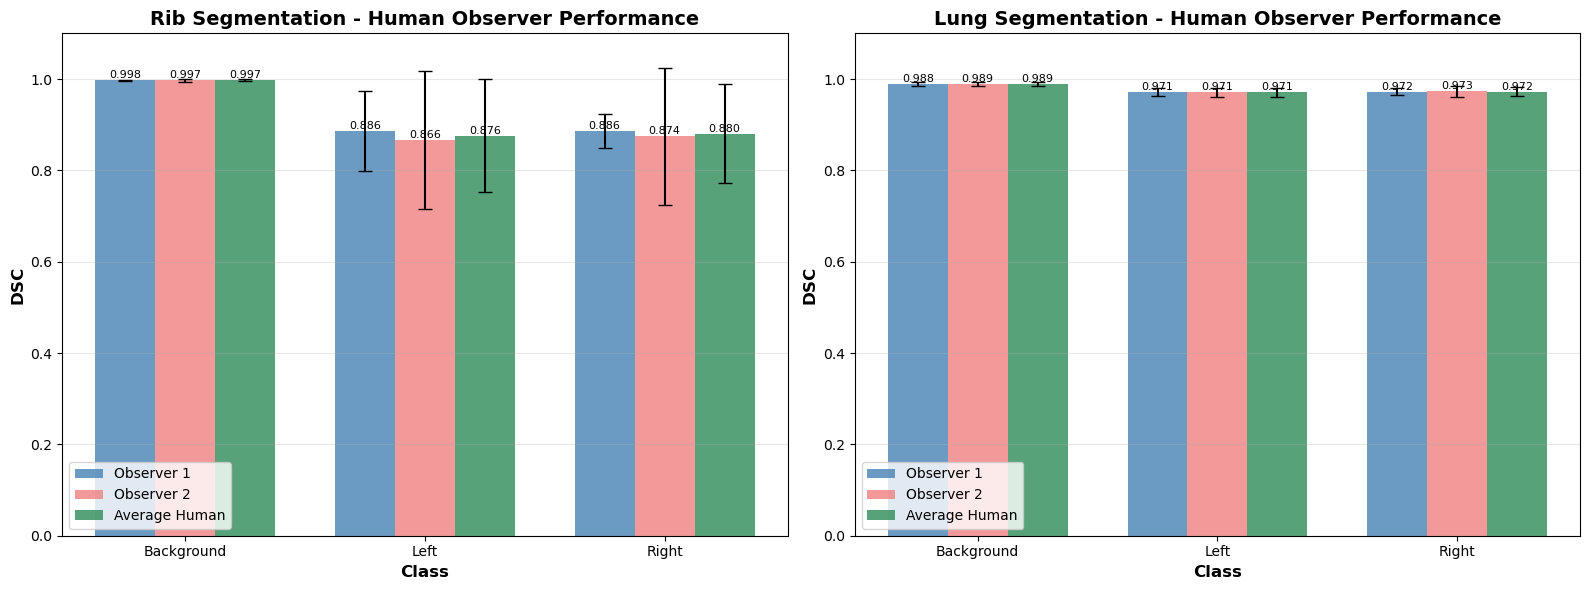


✓ Visualization saved to: ../human_observer_comparison.png


In [52]:
import matplotlib.pyplot as plt
import numpy as np

# Create comparison bar plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

structures_plot = ['Rib', 'Lung']
class_labels = ['Background', 'Left', 'Right']
x = np.arange(len(class_labels))
width = 0.25

for idx, structure in enumerate(structures_plot):
    ax = axes[idx]
    
    if structure == 'Rib':
        obs1_vals = [obs1_rib_mean[f'class_{i}'] for i in range(3)]
        obs2_vals = [obs2_rib_mean[f'class_{i}'] for i in range(3)]
        avg_vals = [rib_avg_dsc[f'class_{i}'] for i in range(3)]
        obs1_err = [obs1_rib_std[f'class_{i}'] for i in range(3)]
        obs2_err = [obs2_rib_std[f'class_{i}'] for i in range(3)]
        avg_err = [rib_avg_std[f'class_{i}'] for i in range(3)]
    else:
        obs1_vals = [obs1_lung_mean[f'class_{i}'] for i in range(3)]
        obs2_vals = [obs2_lung_mean[f'class_{i}'] for i in range(3)]
        avg_vals = [lung_avg_dsc[f'class_{i}'] for i in range(3)]
        obs1_err = [obs1_lung_std[f'class_{i}'] for i in range(3)]
        obs2_err = [obs2_lung_std[f'class_{i}'] for i in range(3)]
        avg_err = [lung_avg_std[f'class_{i}'] for i in range(3)]
    
    # Create bars
    bars1 = ax.bar(x - width, obs1_vals, width, label='Observer 1', 
                   yerr=obs1_err, capsize=5, alpha=0.8, color='steelblue')
    bars2 = ax.bar(x, obs2_vals, width, label='Observer 2',
                   yerr=obs2_err, capsize=5, alpha=0.8, color='lightcoral')
    bars3 = ax.bar(x + width, avg_vals, width, label='Average Human',
                   yerr=avg_err, capsize=5, alpha=0.8, color='seagreen')
    
    # Add value labels on bars
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}',
                   ha='center', va='bottom', fontsize=8)
    
    ax.set_xlabel('Class', fontsize=12, fontweight='bold')
    ax.set_ylabel('DSC', fontsize=12, fontweight='bold')
    ax.set_title(f'{structure} Segmentation - Human Observer Performance', 
                fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(class_labels)
    ax.legend(fontsize=10)
    ax.set_ylim([0, 1.1])
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../human_observer_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved to: ../human_observer_comparison.png")